In [30]:
import os
import re
import glob
import math
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from skimage.morphology import skeletonize, remove_small_objects
from skimage.feature import local_binary_pattern

try:
    from skimage.feature import graycomatrix, graycoprops
except ImportError:
    from skimage.feature import greycomatrix as graycomatrix
    from skimage.feature import greycoprops as graycoprops

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available. XGBRegressor will be skipped.")
    print(e)

In [31]:
# ============================================================
# USER PATHS
# ============================================================

CSV_PATH = "/kaggle/input/datasets/younasafridi/final-labelled-csv1/final-labelled-csv.csv"

IMAGE_DIR = "/kaggle/input/datasets/younasafridi/msc-research1/MS Mining Engineering"

OUTPUT_DIR = "/kaggle/working/gsi_rock_mass_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# GENERAL PARAMETERS
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Image resizing
MAX_IMAGE_SIZE = 768

# Fracture extraction
MIN_FRACTURE_OBJECT_SIZE = 20

# GLCM texture parameters
GLCM_DISTANCES = [1, 2, 4, 8]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_LEVELS = 32

# LBP texture parameters
LBP_SETTINGS = [
    {"radius": 1, "points": 8},
    {"radius": 2, "points": 16},
    {"radius": 3, "points": 24},
]

print("Output folder:", OUTPUT_DIR)

Output folder: /kaggle/working/gsi_rock_mass_outputs


In [32]:
def clean_column_names(df):
    df.columns = [
        str(c).strip().replace("\n", " ").replace("\t", " ")
        for c in df.columns
    ]
    return df


def find_gsi_column(df):
    possible_cols = [
        "GSI Value", "GSI", "GSI_Value", "GSI value",
        "gsi", "gsi_value", "GSI_value"
    ]

    for col in possible_cols:
        if col in df.columns:
            return col

    for col in df.columns:
        if "gsi" in col.lower():
            return col

    raise ValueError("Could not find GSI column. Rename it as 'GSI Value' or 'GSI'.")


def find_id_column(df):
    possible_cols = [
        "RM_ID", "Image_ID", "image_id", "ID", "id",
        "filename", "file", "image", "Image"
    ]

    for col in possible_cols:
        if col in df.columns:
            return col

    raise ValueError("Could not find image ID column. Expected column like 'RM_ID' or 'filename'.")


def build_image_index(image_dir):
    image_files = []

    for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp"]:
        image_files.extend(
            glob.glob(os.path.join(image_dir, "**", ext), recursive=True)
        )

    image_index = {}

    for path in image_files:
        base = os.path.basename(path)
        name = os.path.splitext(base)[0]

        keys = set()
        keys.add(base.lower())
        keys.add(name.lower())

        cleaned = re.sub(r"[^a-zA-Z0-9_]", "", name).lower()
        keys.add(cleaned)

        # Add numeric-only key if present
        nums = re.findall(r"\d+", name)
        for n in nums:
            keys.add(n)
            keys.add(str(int(n)) if n.isdigit() else n)

        for key in keys:
            image_index[key] = path

    return image_index


def match_image_path(image_id, image_index):
    s = str(image_id).strip()
    base = os.path.basename(s)
    name = os.path.splitext(base)[0]

    candidates = [
        s.lower(),
        base.lower(),
        name.lower(),
        re.sub(r"[^a-zA-Z0-9_]", "", name).lower()
    ]

    # Numeric IDs like 195 can match RM_0195.png
    nums = re.findall(r"\d+", s)
    for n in nums:
        try:
            num_int = int(n)
            candidates.extend([
                str(num_int),
                f"{num_int:03d}",
                f"{num_int:04d}",
                f"rm_{num_int:03d}",
                f"rm_{num_int:04d}",
                f"rm{num_int:03d}",
                f"rm{num_int:04d}",
            ])
        except:
            pass

    # Exact match
    for c in candidates:
        if c in image_index:
            return image_index[c]

    # Try extension-based match
    for ext in [".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]:
        c = (name + ext).lower()
        if c in image_index:
            return image_index[c]

    # Partial match
    for key, path in image_index.items():
        for c in candidates:
            if len(c) >= 3 and (c in key or key in c):
                return path

    return None

In [33]:
# ============================================================
# Cell 4: Load CSV, clean RM_ID tabs, and match images
# ============================================================

df = pd.read_csv(CSV_PATH)
df = clean_column_names(df)

gsi_col = find_gsi_column(df)
id_col = find_id_column(df)

print("Detected ID column:", id_col)
print("Detected GSI column:", gsi_col)

# ------------------------------------------------------------
# Clean RM_ID values
# This removes actual tabs, literal "\t", spaces, newline characters,
# and keeps IDs like RM_0004, RM_0010, etc.
# ------------------------------------------------------------

def clean_rm_id_value(x):
    s = str(x)

    # remove actual tab/newline characters
    s = s.replace("\t", "")
    s = s.replace("\n", "")
    s = s.replace("\r", "")

    # remove literal text like \t if present in CSV
    s = s.replace("\\t", "")

    # remove extra spaces
    s = s.strip()
    s = re.sub(r"\s+", "", s)

    # extract standard RM ID pattern
    match = re.search(r"RM[_-]?\d+", s, flags=re.IGNORECASE)

    if match:
        clean_id = match.group(0).upper()
        clean_id = clean_id.replace("-", "_")

        # make sure RM0004 becomes RM_0004
        clean_id = re.sub(r"RM_?", "RM_", clean_id)

        return clean_id

    return s


# Keep original ID for checking, then clean the main ID column
df[id_col + "_raw"] = df[id_col]
df[id_col] = df[id_col].apply(clean_rm_id_value)

# Convert GSI column to numeric
df[gsi_col] = pd.to_numeric(df[gsi_col], errors="coerce")
df = df.dropna(subset=[gsi_col]).copy()

# Build image index and match image paths
image_index = build_image_index(IMAGE_DIR)

print("Total image keys found:", len(image_index))

df["image_path"] = df[id_col].apply(lambda x: match_image_path(x, image_index))

matched_df = df.dropna(subset=["image_path"]).copy()

print("Total labelled records in CSV:", len(df))
print("Total matched image records:", len(matched_df))

display(matched_df[[id_col, gsi_col, "image_path"]].head())

if len(matched_df) < 20:
    raise ValueError("Very few images matched. Please check CSV_PATH, IMAGE_DIR, and image ID format.")

Detected ID column: RM_ID
Detected GSI column: GSI Value
Total image keys found: 1080
Total labelled records in CSV: 236
Total matched image records: 236


,RM_ID,GSI Value,image_path
0,RM_0004,40,/kaggle/input/datasets/younasafridi/msc-resear...
1,RM_0010,25,/kaggle/input/datasets/younasafridi/msc-resear...
2,RM_0012,45,/kaggle/input/datasets/younasafridi/msc-resear...
3,RM_0013,60,/kaggle/input/datasets/younasafridi/msc-resear...
4,RM_0019,25,/kaggle/input/datasets/younasafridi/msc-resear...


In [34]:
# ============================================================
# Cell 5: Improved joint/fracture detection
# Help taken only for fracture detection from the uploaded file
# ============================================================

from scipy import ndimage
from scipy.ndimage import map_coordinates

SQRT2 = math.sqrt(2.0)


def load_grayscale_image(path, max_size=768):
    """
    Load image as grayscale and resize it if the image is very large.
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {path}")

    h, w = img.shape[:2]
    max_dim = max(h, w)

    if max_dim > max_size:
        scale = max_size / max_dim
        new_w = int(w * scale)
        new_h = int(h * scale)
        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    return img


def rescale01(image):
    """
    Rescale image values to 0-1 range.
    """
    image = image.astype(np.float32, copy=False)
    min_val = float(np.min(image))
    max_val = float(np.max(image))

    if max_val - min_val < 1e-8:
        return np.zeros_like(image, dtype=np.float32)

    return ((image - min_val) / (max_val - min_val)).astype(np.float32)


def normalize_gray(gray):
    """
    Local normalization.
    It suppresses illumination variation and enhances local dark line structures.
    """
    gray = gray.astype(np.float32)

    if gray.max() > 1.5:
        gray = gray / 255.0

    smoothed = ndimage.gaussian_filter(gray, sigma=1.0)
    background = ndimage.gaussian_filter(smoothed, sigma=18.0)

    high_pass = smoothed - background

    local_std = np.sqrt(
        ndimage.gaussian_filter((high_pass ** 2).astype(np.float32), sigma=9.0) + 1e-6
    )

    normalized = high_pass / (local_std + 1e-4)
    normalized = rescale01(normalized)

    return normalized


def otsu_threshold(image, bins=256):
    """
    Otsu threshold for 0-1 response image.
    """
    values = np.clip(image.astype(np.float64).ravel(), 0.0, 1.0)

    hist, bin_edges = np.histogram(values, bins=bins, range=(0.0, 1.0))
    hist = hist.astype(np.float64)

    if hist.sum() == 0:
        return 0.5

    prob = hist / hist.sum()
    centers = (bin_edges[:-1] + bin_edges[1:]) * 0.5

    omega = np.cumsum(prob)
    mu = np.cumsum(prob * centers)
    mu_t = mu[-1]

    denom = omega * (1.0 - omega)

    sigma_b_sq = np.zeros_like(denom)
    valid = denom > 0

    sigma_b_sq[valid] = ((mu_t * omega[valid] - mu[valid]) ** 2) / denom[valid]

    idx = int(np.argmax(sigma_b_sq))

    return float(centers[idx])


def paper_lowpass_kernel():
    """
    Low-pass kernel used before high-frequency fracture enhancement.
    """
    kernel = np.array(
        [
            [0.0, 1 / 52, 1 / 26, 1 / 52, 0.0],
            [1 / 52, 3 / 52, 1 / 13, 3 / 52, 1 / 52],
            [1 / 26, 1 / 13, 1 / 13, 1 / 13, 1 / 26],
            [1 / 52, 3 / 52, 1 / 13, 3 / 52, 1 / 52],
            [0.0, 1 / 52, 1 / 26, 1 / 52, 0.0],
        ],
        dtype=np.float32,
    )

    return kernel / float(kernel.sum())


def paper_highpass_kernel():
    """
    High-pass kernel for thin line enhancement.
    """
    return np.array(
        [
            [-1.0, -1.0, -1.0],
            [-1.0, 8.0, -1.0],
            [-1.0, -1.0, -1.0],
        ],
        dtype=np.float32,
    ) / 9.0


def paper_style_response(gray):
    """
    Fracture response using smoothing, high-pass filtering, black-hat,
    and local contrast.
    """
    smoothed = ndimage.median_filter(gray.astype(np.float32), size=3)
    smoothed = ndimage.convolve(smoothed, paper_lowpass_kernel(), mode="reflect")

    high_freq = ndimage.convolve(smoothed, paper_highpass_kernel(), mode="reflect")

    dark_line = rescale01(-high_freq)
    line_edge = rescale01(np.abs(high_freq))

    black_hat = ndimage.grey_closing(smoothed, size=(9, 9)) - smoothed
    black_hat = rescale01(black_hat)

    local_contrast = rescale01(
        np.abs(smoothed - ndimage.gaussian_filter(smoothed, sigma=5.0))
    )

    response = (
        0.48 * dark_line
        + 0.22 * line_edge
        + 0.20 * black_hat
        + 0.10 * local_contrast
    )

    return rescale01(response)


def line_support_kernels(size=9):
    """
    Directional line-support kernels for horizontal, vertical, and diagonal joints.
    """
    center = size // 2

    line_sets = [
        [(center, col) for col in range(size)],
        [(row, center) for row in range(size)],
        [(idx, idx) for idx in range(size)],
        [(idx, size - 1 - idx) for idx in range(size)],
    ]

    kernels = []

    for line in line_sets:
        kernel = np.ones((size, size), dtype=np.float32)

        for row, col in line:
            kernel[row, col] = 0.0

        kernel /= float(kernel.sum())

        for row, col in line:
            kernel[row, col] = -1.0 / float(len(line))

        kernels.append(kernel)

    return kernels


def directional_line_response(gray):
    """
    Detect line-like dark structures in multiple directions and scales.
    """
    smoothed = ndimage.gaussian_filter(gray.astype(np.float32), sigma=0.8)

    dark_responses = []
    abs_responses = []

    for size in (7, 11):
        for kernel in line_support_kernels(size):
            response = ndimage.convolve(smoothed, kernel, mode="reflect")

            dark_responses.append(response)
            abs_responses.append(np.abs(response))

    dark_line = np.maximum.reduce(dark_responses)
    signed_line = np.maximum.reduce(abs_responses)

    response = 0.75 * rescale01(dark_line) + 0.25 * rescale01(signed_line)

    return rescale01(response)


def hessian_eigensystem(image, sigma):
    """
    Hessian eigenvalue calculation for line-like structure detection.
    """
    hxx = ndimage.gaussian_filter(image, sigma=sigma, order=(0, 2)) * (sigma ** 2)
    hxy = ndimage.gaussian_filter(image, sigma=sigma, order=(1, 1)) * (sigma ** 2)
    hyy = ndimage.gaussian_filter(image, sigma=sigma, order=(2, 0)) * (sigma ** 2)

    tmp = np.sqrt(np.maximum((hxx - hyy) ** 2 + 4.0 * (hxy ** 2), 0.0))

    eig1 = 0.5 * (hxx + hyy + tmp)
    eig2 = 0.5 * (hxx + hyy - tmp)

    swap = np.abs(eig1) > np.abs(eig2)

    lambda1 = np.where(swap, eig2, eig1)
    lambda2 = np.where(swap, eig1, eig2)

    normal_angle = 0.5 * np.arctan2(2.0 * hxy, hxx - hyy + 1e-12)

    return lambda1.astype(np.float32), lambda2.astype(np.float32), normal_angle.astype(np.float32)


def frangi_dark_response(gray, sigmas=(1.0, 2.0, 3.0, 4.0)):
    """
    Multiscale Hessian/Frangi-like response for dark fracture lines.
    """
    inverted = 1.0 - gray

    best_response = np.zeros_like(gray, dtype=np.float32)
    best_angle = np.zeros_like(gray, dtype=np.float32)

    beta_sq = 0.5 ** 2

    for sigma in sigmas:
        lambda1, lambda2, normal_angle = hessian_eigensystem(inverted, sigma=sigma)

        rb = (lambda1 / (lambda2 + 1e-6)) ** 2
        s2 = lambda1 ** 2 + lambda2 ** 2

        c_sq = float(np.percentile(s2, 95)) + 1e-6

        vessel = np.exp(-rb / (2.0 * beta_sq)) * (
            1.0 - np.exp(-s2 / (2.0 * c_sq))
        )

        vessel = vessel.astype(np.float32)

        vessel[lambda2 >= 0.0] = 0.0

        update = vessel > best_response

        best_response[update] = vessel[update]
        best_angle[update] = normal_angle[update]

    return rescale01(best_response), best_angle


def sample_along_offsets(image, yy, xx):
    """
    Sample image values at floating-point coordinates.
    """
    coords = np.vstack([yy.ravel(), xx.ravel()])

    samples = map_coordinates(
        image,
        coords,
        order=1,
        mode="reflect"
    )

    return samples.reshape(yy.shape).astype(np.float32)


def valley_emphasis(gray, normal_angle, offsets=(1.5, 2.5, 3.5)):
    """
    Emphasize valley-like structures where the center line is darker than both sides.
    """
    rows, cols = gray.shape

    yy, xx = np.mgrid[0:rows, 0:cols].astype(np.float32)

    center = gray.astype(np.float32)

    best = np.zeros_like(center, dtype=np.float32)

    cos_a = np.cos(normal_angle)
    sin_a = np.sin(normal_angle)

    for offset in offsets:
        dx = cos_a * offset
        dy = sin_a * offset

        left = sample_along_offsets(gray, yy - dy, xx - dx)
        right = sample_along_offsets(gray, yy + dy, xx + dx)

        contrast = 0.5 * (left + right) - center
        symmetry = np.minimum(left - center, right - center)

        score = np.maximum(np.minimum(contrast, symmetry), 0.0)

        best = np.maximum(best, score)

    return rescale01(best)


def adaptive_response_mask(
    response,
    otsu_scale=0.9,
    min_fraction=0.02,
    max_fraction=0.24
):
    """
    Adaptive thresholding with minimum and maximum allowed fracture area fraction.
    """
    response = rescale01(response)

    if float(response.max()) <= 0.0:
        return np.zeros_like(response, dtype=bool), 1.0

    max_fraction = min(max(max_fraction, 1e-4), 0.95)
    min_fraction = min(max(min_fraction, 0.0), max_fraction)

    threshold = max(
        otsu_threshold(response) * otsu_scale,
        float(np.quantile(response, 1.0 - max_fraction))
    )

    mask = response >= threshold

    if min_fraction > 0.0 and float(mask.mean()) < min_fraction:
        threshold = min(
            threshold,
            float(np.quantile(response, 1.0 - min_fraction))
        )

        mask = response >= threshold

    if float(mask.mean()) > max_fraction:
        threshold = max(
            threshold,
            float(np.quantile(response, 1.0 - max_fraction))
        )

        mask = response >= threshold

    return mask.astype(bool), float(threshold)


def remove_small_components(binary_mask, min_size):
    """
    Remove small connected components from binary fracture mask.
    """
    labeled, count = ndimage.label(
        binary_mask,
        structure=np.ones((3, 3), dtype=bool)
    )

    cleaned = np.zeros_like(binary_mask, dtype=bool)

    component_slices = ndimage.find_objects(labeled)

    for component_id in range(1, count + 1):
        component_slice = component_slices[component_id - 1]

        if component_slice is None:
            continue

        component = labeled[component_slice] == component_id

        if int(component.sum()) >= min_size:
            cleaned_view = cleaned[component_slice]
            cleaned_view[component] = True

    return cleaned


def clean_candidate_mask(binary_mask, score_map):
    """
    Clean fracture candidate mask and control over-detection.
    """
    area = int(binary_mask.size)

    cleaned = ndimage.binary_closing(
        binary_mask,
        structure=np.ones((3, 3), dtype=bool)
    )

    cleaned = remove_small_components(
        cleaned,
        min_size=max(8, area // 18000)
    )

    if float(cleaned.mean()) > 0.24:
        cutoff = float(np.quantile(score_map, 0.76))
        cleaned &= score_map >= cutoff

        cleaned = remove_small_components(
            cleaned,
            min_size=max(8, area // 16000)
        )

    return cleaned.astype(bool)


def component_elongation(coords):
    """
    Component elongation based on eigenvalues of coordinate covariance.
    Line-like fractures should be elongated.
    """
    if len(coords) < 3:
        return 1.0

    centered = coords.astype(np.float32) - coords.mean(axis=0, keepdims=True)

    cov = np.cov(centered.T)

    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(np.maximum(eigvals, 1e-6))

    return float(math.sqrt(eigvals[-1] / eigvals[0]))


def filter_components(binary_mask, score_map):
    """
    Remove weak, small, and nearly round components.
    This keeps more line-like fracture objects.
    """
    labeled, count = ndimage.label(
        binary_mask,
        structure=np.ones((3, 3), dtype=bool)
    )

    filtered = np.zeros_like(binary_mask, dtype=bool)

    component_slices = ndimage.find_objects(labeled)

    for component_id in range(1, count + 1):
        component_slice = component_slices[component_id - 1]

        if component_slice is None:
            continue

        component = labeled[component_slice] == component_id

        local_coords = np.argwhere(component)

        coords = local_coords + np.array(
            [component_slice[0].start, component_slice[1].start],
            dtype=np.int64
        )

        area = int(component.sum())

        if area < 10:
            continue

        mean_score = float(score_map[component_slice][component].mean())
        elongation = component_elongation(coords)

        if mean_score < 0.065 and area < 35:
            continue

        if elongation < 1.10 and area < 70:
            continue

        filtered_view = filtered[component_slice]
        filtered_view[component] = True

    return filtered


def morphological_skeleton(binary_mask):
    """
    Skeletonize binary fracture mask.
    """
    return skeletonize(binary_mask.astype(bool)).astype(bool)


def prune_skeleton(binary_skeleton, iterations=1):
    """
    Remove very small terminal branches from the skeleton.
    """
    skeleton_img = binary_skeleton.copy()

    kernel = np.ones((3, 3), dtype=np.uint8)
    kernel[1, 1] = 0

    for _ in range(iterations):
        neighbor_count = ndimage.convolve(
            skeleton_img.astype(np.uint8),
            kernel,
            mode="constant",
            cval=0
        )

        endpoints = skeleton_img & (neighbor_count <= 1)

        if not endpoints.any():
            break

        skeleton_img = skeleton_img & ~endpoints

    return skeleton_img


def skeleton_length(binary_skeleton):
    """
    Estimate skeleton length using horizontal, vertical, and diagonal connections.
    """
    mask = binary_skeleton.astype(bool)

    horizontal = mask[:, :-1] & mask[:, 1:]
    vertical = mask[:-1, :] & mask[1:, :]

    diag_dr = mask[:-1, :-1] & mask[1:, 1:]
    diag_dl = mask[:-1, 1:] & mask[1:, :-1]

    length = (
        horizontal.sum()
        + vertical.sum()
        + SQRT2 * (diag_dr.sum() + diag_dl.sum())
    )

    return float(length)


def fractal_dimension_box_count(binary_skeleton):
    """
    Box-counting fractal dimension on the fracture skeleton.
    """
    binary_skeleton = binary_skeleton.astype(bool)

    if binary_skeleton.sum() < 10:
        return 0.0

    height, width = binary_skeleton.shape
    min_dim = min(height, width)

    sizes = []
    size = 2

    while size <= min_dim // 2:
        sizes.append(size)
        size *= 2

    if len(sizes) < 2:
        return 0.0

    counts = []

    for box_size in sizes:
        rows = int(math.ceil(height / box_size))
        cols = int(math.ceil(width / box_size))

        count = 0

        for row in range(rows):
            row_slice = slice(
                row * box_size,
                min((row + 1) * box_size, height)
            )

            for col in range(cols):
                col_slice = slice(
                    col * box_size,
                    min((col + 1) * box_size, width)
                )

                if binary_skeleton[row_slice, col_slice].any():
                    count += 1

        counts.append(max(count, 1))

    log_inv_size = np.log(1.0 / np.array(sizes, dtype=np.float64))
    log_count = np.log(np.array(counts, dtype=np.float64))

    slope = float(np.polyfit(log_inv_size, log_count, deg=1)[0])

    return slope


def advanced_detect_fractures(gray):
    """
    Main improved fracture detector.

    Output:
    - normalized gray image
    - combined fracture response
    - display mask
    - skeleton
    - trace skeleton
    - summary features
    """

    gray_float = gray.astype(np.float32)

    if gray_float.max() > 1.5:
        gray_float = gray_float / 255.0

    normalized = normalize_gray(gray_float)

    hessian_response, normal_angle = frangi_dark_response(normalized)

    valley = valley_emphasis(normalized, normal_angle)

    black_hat = ndimage.grey_closing(normalized, size=(9, 9)) - normalized
    black_hat = rescale01(black_hat)

    local_darkness = np.maximum(
        ndimage.gaussian_filter(normalized, sigma=5.0) - normalized,
        0.0
    )
    local_darkness = rescale01(local_darkness)

    paper_response = paper_style_response(normalized)

    line_response = directional_line_response(normalized)

    combined = (
        0.36 * hessian_response
        + 0.19 * valley
        + 0.14 * black_hat
        + 0.21 * paper_response
        + 0.10 * line_response
    )

    combined = rescale01(combined)

    combined_mask, combined_threshold = adaptive_response_mask(
        combined,
        otsu_scale=0.92,
        min_fraction=0.025,
        max_fraction=0.20
    )

    paper_mask, paper_threshold = adaptive_response_mask(
        paper_response,
        otsu_scale=1.02,
        min_fraction=0.018,
        max_fraction=0.14
    )

    line_mask, line_threshold = adaptive_response_mask(
        line_response,
        otsu_scale=1.08,
        min_fraction=0.010,
        max_fraction=0.08
    )

    contrast_guard = (
        (local_darkness > 0.030)
        | (valley > 0.016)
        | (paper_response >= paper_threshold)
        | (line_response >= line_threshold)
    )

    binary_high = (
        (combined >= max(combined_threshold, float(np.quantile(combined, 0.88))))
        | (paper_mask & (hessian_response > 0.12))
    )

    binary_low = (combined_mask | paper_mask | line_mask) & contrast_guard

    binary = ndimage.binary_propagation(
        binary_high,
        mask=binary_low,
        structure=np.ones((3, 3), dtype=bool)
    )

    binary |= combined_mask & contrast_guard

    binary |= line_mask & (combined > float(np.quantile(combined, 0.70)))

    display_mask = clean_candidate_mask(binary, combined)

    display_skeleton = morphological_skeleton(display_mask)

    metric_mask = filter_components(display_mask, combined)

    trace_skeleton = display_skeleton & metric_mask

    trace_skeleton = remove_small_components(trace_skeleton, min_size=6)

    if display_skeleton.any() and float(trace_skeleton.sum()) < 0.35 * float(display_skeleton.sum()):
        trace_skeleton = remove_small_components(display_skeleton, min_size=6)

    trace_skeleton = prune_skeleton(trace_skeleton, iterations=1)

    fd = fractal_dimension_box_count(trace_skeleton)

    height, width = gray.shape
    area = float(height * width)
    diag = float(math.hypot(height, width))

    total_length_px = skeleton_length(trace_skeleton)
    skeleton_pixels = int(trace_skeleton.sum())

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        trace_skeleton.astype(np.uint8),
        connectivity=8
    )

    component_lengths = []

    for i in range(1, num_labels):
        component_lengths.append(stats[i, cv2.CC_STAT_AREA])

    if len(component_lengths) == 0:
        component_lengths = [0]

    component_lengths = np.array(component_lengths)

    summary = {
        "fractal_dimension_box_counting": float(fd),
        "fracture_total_length": float(total_length_px),
        "fracture_skeleton_pixels": int(skeleton_pixels),
        "fracture_density": float(skeleton_pixels / area),
        "fracture_length_density": float(total_length_px / area),
        "fracture_component_count": int(num_labels - 1),
        "fracture_component_mean_length": float(np.mean(component_lengths)),
        "fracture_component_std_length": float(np.std(component_lengths)),
        "fracture_component_max_length": float(np.max(component_lengths)),
        "fracture_response_mean": float(np.mean(combined)),
        "fracture_response_std": float(np.std(combined)),
        "fracture_mask_area_fraction": float(display_mask.mean()),
        "fracture_trace_area_fraction": float(trace_skeleton.mean()),
        "analysis_height_px": int(height),
        "analysis_width_px": int(width),
    }

    return {
        "gray": gray_float,
        "normalized": normalized,
        "response": combined,
        "mask": display_mask.astype(bool),
        "skeleton": display_skeleton.astype(bool),
        "trace_skeleton": trace_skeleton.astype(bool),
        "summary": summary
    }


def extract_fracture_mask(gray):
    """
    Compatibility function for the previous pipeline.
    Returns fracture mask and trace skeleton.
    """
    result = advanced_detect_fractures(gray)

    fracture_mask = result["mask"].astype(np.uint8)
    skeleton_img = result["trace_skeleton"].astype(np.uint8)

    return fracture_mask, skeleton_img


def fracture_geometry_features(skeleton_img):
    """
    Geometry features from the improved fracture skeleton.
    """
    skel = skeleton_img > 0

    h, w = skel.shape
    area = h * w

    total_length = skeleton_length(skel)
    density = float(np.sum(skel) / area)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        skel.astype(np.uint8),
        connectivity=8
    )

    component_lengths = []

    for i in range(1, num_labels):
        component_lengths.append(stats[i, cv2.CC_STAT_AREA])

    if len(component_lengths) == 0:
        component_lengths = [0]

    component_lengths = np.array(component_lengths)

    features = {
        "fracture_total_length": float(total_length),
        "fracture_density": density,
        "fracture_component_count": int(num_labels - 1),
        "fracture_component_mean_length": float(np.mean(component_lengths)),
        "fracture_component_std_length": float(np.std(component_lengths)),
        "fracture_component_max_length": float(np.max(component_lengths)),
    }

    return features

In [35]:
#-------------
# cell 6
#-------------

def extract_glcm_features(gray):
    """
    GLCM features describe second-order texture.
    These features measure contrast, homogeneity, energy, and correlation.
    """

    img = cv2.normalize(
        gray,
        None,
        0,
        GLCM_LEVELS - 1,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    glcm = graycomatrix(
        img,
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True
    )

    props = [
        "contrast",
        "dissimilarity",
        "homogeneity",
        "ASM",
        "energy",
        "correlation"
    ]

    features = {}

    for prop in props:
        values = graycoprops(glcm, prop)

        features[f"glcm_{prop}_mean"] = float(np.mean(values))
        features[f"glcm_{prop}_std"] = float(np.std(values))
        features[f"glcm_{prop}_min"] = float(np.min(values))
        features[f"glcm_{prop}_max"] = float(np.max(values))

    return features


def extract_lbp_features(gray):
    """
    LBP features describe local micro-texture patterns.
    They are useful for roughness and small local variations on rock surfaces.
    """

    features = {}

    img = cv2.normalize(
        gray,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    for setting in LBP_SETTINGS:
        radius = setting["radius"]
        points = setting["points"]

        lbp = local_binary_pattern(
            img,
            P=points,
            R=radius,
            method="uniform"
        )

        n_bins = points + 2

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_bins + 1),
            range=(0, n_bins),
            density=True
        )

        for i, val in enumerate(hist):
            features[f"lbp_r{radius}_p{points}_bin_{i}"] = float(val)

        features[f"lbp_r{radius}_p{points}_mean"] = float(np.mean(lbp))
        features[f"lbp_r{radius}_p{points}_std"] = float(np.std(lbp))
        features[f"lbp_r{radius}_p{points}_entropy"] = float(
            -np.sum(hist * np.log2(hist + 1e-12))
        )

    return features


def extract_intensity_features(gray):
    """
    Basic grayscale statistics.
    These features capture global brightness and contrast information.
    """

    pixels = gray.ravel().astype(np.float32)

    features = {
        "intensity_mean": float(np.mean(pixels)),
        "intensity_std": float(np.std(pixels)),
        "intensity_min": float(np.min(pixels)),
        "intensity_max": float(np.max(pixels)),
        "intensity_median": float(np.median(pixels)),
        "intensity_p10": float(np.percentile(pixels, 10)),
        "intensity_p25": float(np.percentile(pixels, 25)),
        "intensity_p75": float(np.percentile(pixels, 75)),
        "intensity_p90": float(np.percentile(pixels, 90)),
    }

    return features

In [36]:
# ============================================================
# Cell 7: Complete feature extraction using improved fracture detector
# ============================================================

def extract_all_features(image_path, save_debug=False, debug_name=None):
    """
    Extract all features from one image:
    1. Improved fracture detection
    2. Fractal dimension from fracture skeleton
    3. Fracture geometry features
    4. Intensity features
    5. GLCM features
    6. LBP features
    """

    gray = load_grayscale_image(image_path, MAX_IMAGE_SIZE)

    detection = advanced_detect_fractures(gray)

    fracture_mask = detection["mask"]
    skeleton_img = detection["trace_skeleton"]
    response = detection["response"]

    features = {}

    # Add improved fracture detection summary features
    features.update(detection["summary"])

    # Add grayscale image features
    features.update(extract_intensity_features(gray))

    # Add GLCM texture features
    features.update(extract_glcm_features(gray))

    # Add LBP texture features
    features.update(extract_lbp_features(gray))

    if save_debug:
        # Create better overlay:
        # Green = detected fracture mask
        # Red = skeleton used for fractal dimension
        gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0

        overlay = gray_rgb.copy()

        overlay[fracture_mask] = (
            0.65 * overlay[fracture_mask]
            + 0.35 * np.array([0.0, 1.0, 0.0], dtype=np.float32)
        )

        overlay[skeleton_img] = np.array([1.0, 0.0, 0.0], dtype=np.float32)

        overlay_uint8 = np.clip(overlay * 255, 0, 255).astype(np.uint8)

        debug_path = os.path.join(
            OUTPUT_DIR,
            f"{debug_name}_improved_fracture_overlay.png"
        )

        cv2.imwrite(debug_path, cv2.cvtColor(overlay_uint8, cv2.COLOR_RGB2BGR))

        # Save response map also
        response_uint8 = np.clip(response * 255, 0, 255).astype(np.uint8)

        response_path = os.path.join(
            OUTPUT_DIR,
            f"{debug_name}_fracture_response.png"
        )

        cv2.imwrite(response_path, response_uint8)

        # Save skeleton only
        skeleton_path = os.path.join(
            OUTPUT_DIR,
            f"{debug_name}_fracture_skeleton.png"
        )

        cv2.imwrite(skeleton_path, (skeleton_img.astype(np.uint8) * 255))

    return features


feature_rows = []

for idx, row in matched_df.iterrows():
    image_id = str(row[id_col])
    image_path = row["image_path"]
    gsi_value = row[gsi_col]

    try:
        # Save debug overlays for first 10 images
        save_debug = len(feature_rows) < 10

        safe_name = re.sub(r"[^a-zA-Z0-9_]", "_", image_id)

        features = extract_all_features(
            image_path=image_path,
            save_debug=save_debug,
            debug_name=safe_name
        )

        features[id_col] = image_id
        features["image_path"] = image_path
        features["GSI"] = gsi_value

        feature_rows.append(features)

    except Exception as e:
        print(f"Feature extraction failed for {image_id}: {e}")

features_df = pd.DataFrame(feature_rows)

print("Final feature table shape:", features_df.shape)

display(features_df.head())

features_excel_path = os.path.join(
    OUTPUT_DIR,
    "rock_mass_extracted_features_improved_fractures.xlsx"
)

features_df.to_excel(features_excel_path, index=False)

print("Saved extracted features to:")
print(features_excel_path)

Final feature table shape: (236, 114)


,fractal_dimension_box_counting,fracture_total_length,fracture_skeleton_pixels,fracture_density,fracture_length_density,fracture_component_count,fracture_component_mean_length,fracture_component_std_length,fracture_component_max_length,fracture_response_mean,...,lbp_r3_p24_bin_22,lbp_r3_p24_bin_23,lbp_r3_p24_bin_24,lbp_r3_p24_bin_25,lbp_r3_p24_mean,lbp_r3_p24_std,lbp_r3_p24_entropy,RM_ID,image_path,GSI
0,1.501619,22319.305612,18102,0.044556,0.054937,253,71.549407,249.730294,2636.0,0.091581,...,0.031115,0.025052,0.061370,0.436939,17.598542,9.130788,3.484889,RM_0004,/kaggle/input/datasets/younasafridi/msc-resear...,40
1,1.576138,28861.745079,25003,0.056521,0.065244,653,38.289433,44.248745,416.0,0.119059,...,0.025669,0.042598,0.071129,0.553422,19.190448,9.095862,2.801054,RM_0010,/kaggle/input/datasets/younasafridi/msc-resear...,25
2,1.508095,18266.516872,15209,0.053960,0.064808,400,38.022500,52.395630,474.0,0.111125,...,0.025116,0.035309,0.066907,0.562716,19.073754,9.267783,2.775691,RM_0012,/kaggle/input/datasets/younasafridi/msc-resear...,45
3,1.512562,18573.493711,15225,0.054612,0.066623,348,43.750000,76.781659,623.0,0.108520,...,0.024905,0.035418,0.067246,0.558472,19.068652,9.218681,2.806689,RM_0013,/kaggle/input/datasets/younasafridi/msc-resear...,60
4,1.536068,19589.227550,16543,0.058534,0.069312,544,30.409926,51.205497,621.0,0.137368,...,0.024471,0.044016,0.079137,0.603445,19.889939,9.062028,2.433956,RM_0019,/kaggle/input/datasets/younasafridi/msc-resear...,25


Saved extracted features to:
/kaggle/working/gsi_rock_mass_outputs/rock_mass_extracted_features_improved_fractures.xlsx


In [37]:
non_feature_cols = [id_col, "image_path", "GSI"]

feature_cols = [
    c for c in features_df.columns
    if c not in non_feature_cols
]

X = features_df[feature_cols].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

y = features_df["GSI"].astype(float).values

# Stratified split using GSI bins
try:
    y_bins = pd.qcut(y, q=5, duplicates="drop")
    stratify_arg = y_bins
except Exception:
    stratify_arg = None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_arg
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training samples: 188
Testing samples: 48
Number of features: 111


In [38]:
models = {}

models["SVR_RBF"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=50,
        gamma="scale",
        epsilon=2.0
    ))
])

models["Random_Forest"] = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

estimators_for_stack = [
    ("svr", models["SVR_RBF"]),
    ("rf", models["Random_Forest"])
]

if XGBOOST_AVAILABLE:
    estimators_for_stack.append(("xgb", models["XGBoost"]))

models["Stacking_Combined"] = StackingRegressor(
    estimators=estimators_for_stack,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

print("Models prepared:")
for name in models.keys():
    print(name)

Models prepared:
SVR_RBF
Random_Forest
XGBoost
Stacking_Combined


In [39]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    }


metrics_list = []
predictions = {}
trained_models = {}

for model_name, model in models.items():
    print("\nTraining:", model_name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    m = regression_metrics(y_test, y_pred)
    m["Model"] = model_name

    metrics_list.append(m)

metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df[["Model", "R2", "MSE", "RMSE", "MAE"]]

print("\nModel performance on hold-out test set:")
display(metrics_df)

metrics_path = os.path.join(
    OUTPUT_DIR,
    "model_performance_metrics.xlsx"
)

metrics_df.to_excel(metrics_path, index=False)

print("Saved model metrics to:")
print(metrics_path)


Training: SVR_RBF

Training: Random_Forest

Training: XGBoost

Training: Stacking_Combined

Model performance on hold-out test set:


,Model,R2,MSE,RMSE,MAE
0,SVR_RBF,0.756242,91.465146,9.563741,7.289543
1,Random_Forest,0.746592,95.086000,9.751205,7.158282
2,XGBoost,0.831348,63.283019,7.955062,6.041353
3,Stacking_Combined,0.832761,62.752912,7.921674,6.332672


Saved model metrics to:
/kaggle/working/gsi_rock_mass_outputs/model_performance_metrics.xlsx


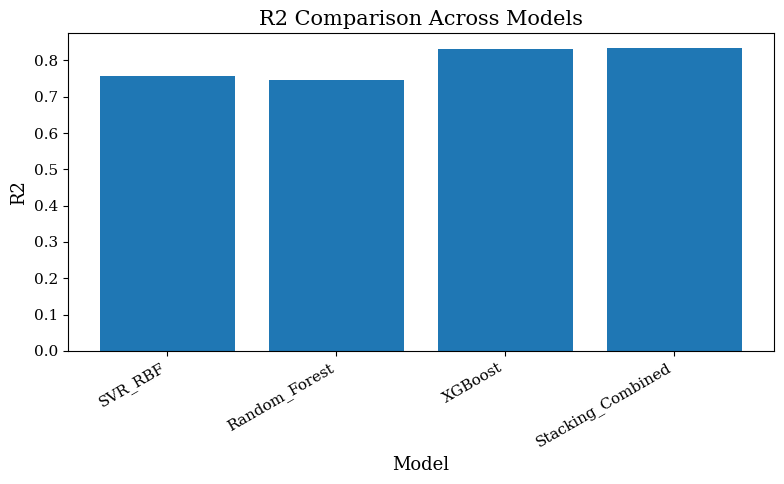

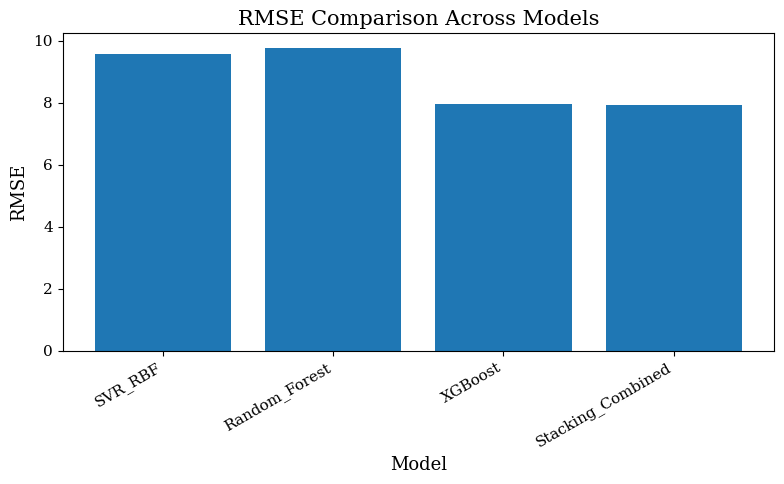

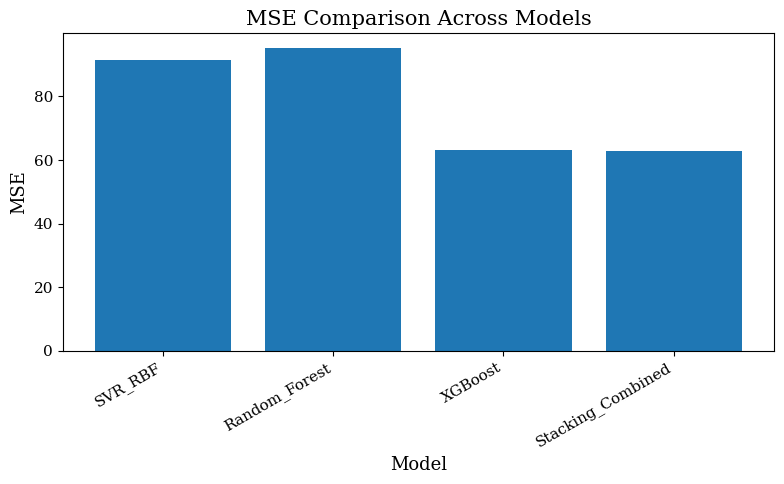

In [40]:
def plot_bar(metrics_df, metric_name, output_path):
    plt.figure(figsize=(8, 5))
    plt.bar(metrics_df["Model"], metrics_df[metric_name])
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Comparison Across Models")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


plot_bar(
    metrics_df,
    "R2",
    os.path.join(OUTPUT_DIR, "r2_score_comparison.png")
)

plot_bar(
    metrics_df,
    "RMSE",
    os.path.join(OUTPUT_DIR, "rmse_comparison.png")
)

plot_bar(
    metrics_df,
    "MSE",
    os.path.join(OUTPUT_DIR, "mse_comparison.png")
)

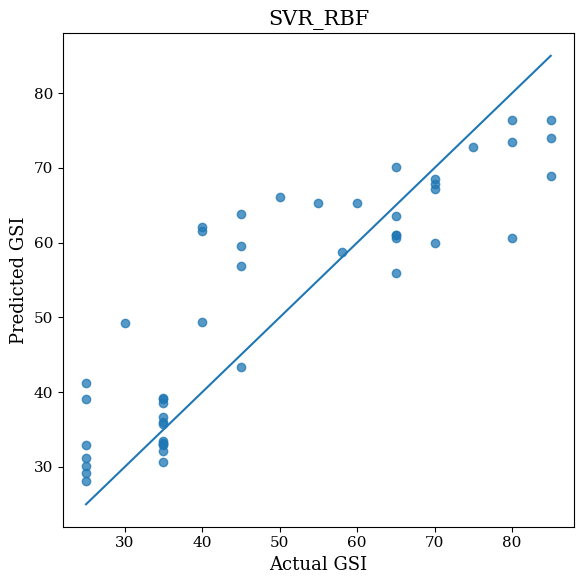

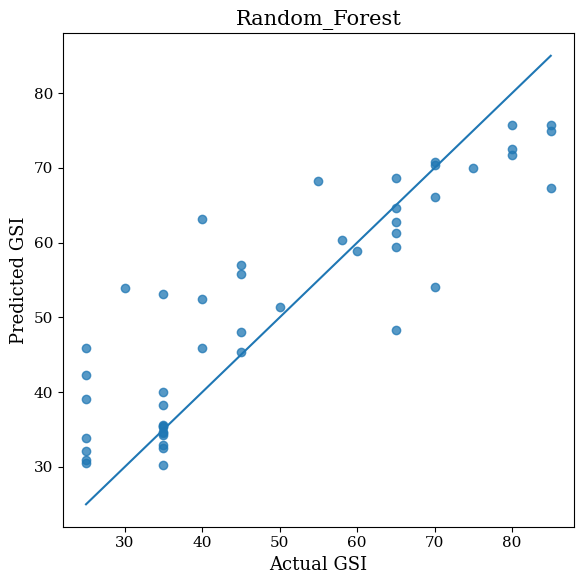

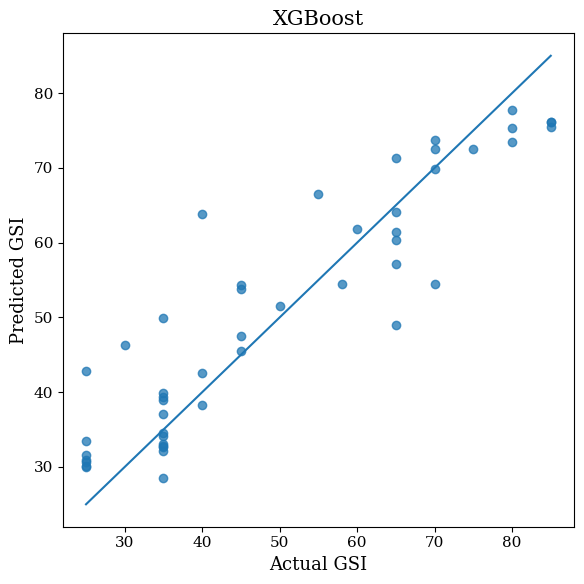

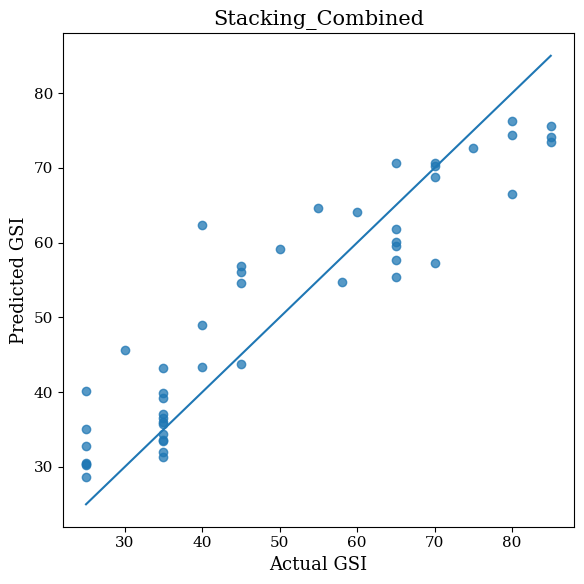

In [41]:
def plot_predicted_vs_actual(y_true, preds_dict, output_dir):
    for model_name, y_pred in preds_dict.items():
        plt.figure(figsize=(6, 6))

        plt.scatter(y_true, y_pred, alpha=0.75)

        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))

        plt.plot([min_val, max_val], [min_val, max_val])

        plt.xlabel("Actual GSI")
        plt.ylabel("Predicted GSI")
        plt.title(f"{model_name}")

        plt.tight_layout()

        save_path = os.path.join(
            output_dir,
            f"{model_name}.png"
        )

        plt.savefig(save_path, dpi=300)
        plt.show()


plot_predicted_vs_actual(y_test, predictions, OUTPUT_DIR)

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Clean names for the classical ML models only
MODEL_LABELS = {
    "SVR_RBF": "SVR-RBF",
    "Random_Forest": "Random Forest",
    "XGBoost": "XGBoost",
    "Stacking_Ensemble": "Stacking Ensemble",
    "Stacking_Combined": "Stacking Ensemble"
}

# Attractive thesis-style formatting
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "savefig.dpi": 600
})

In [43]:
def plot_bar(metrics_df, metric_name, output_path):
    """
    Plot comparison of a regression evaluation metric across
    classical machine learning models.
    """

    df = metrics_df.copy()

    # Clean display names
    df["Display_Model"] = df["Model"].apply(
        lambda x: MODEL_LABELS.get(x, x.replace("_", " "))
    )

    model_names = df["Display_Model"].tolist()
    values = df[metric_name].values

    # Select the best model according to the metric
    if metric_name == "R2":
        best_index = int(np.argmax(values))
        ylabel = r"$R^2$"
        
    else:
        best_index = int(np.argmin(values))
        ylabel = metric_name
        

    # Highlight best model
    bar_colors = ["#A9C7E0"] * len(values)
    bar_colors[best_index] = "#1F4E79"

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    bars = ax.bar(
        model_names,
        values,
        color=bar_colors,
        edgecolor="#17365D",
        linewidth=1.0,
        width=0.62
    )

    # Add values above bars
    for i, (bar, value) in enumerate(zip(bars, values)):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.025,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold" if i == best_index else "normal"
        )

    ax.set_xlabel("Models", fontweight="bold", labelpad=10)
    ax.set_ylabel(ylabel, fontweight="bold", labelpad=8)
   
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.40)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(0, max(values) * 1.17)

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

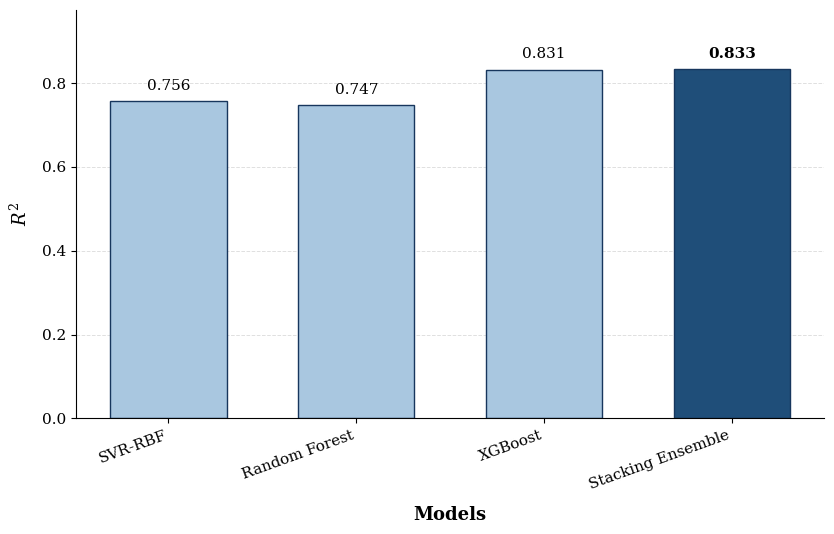

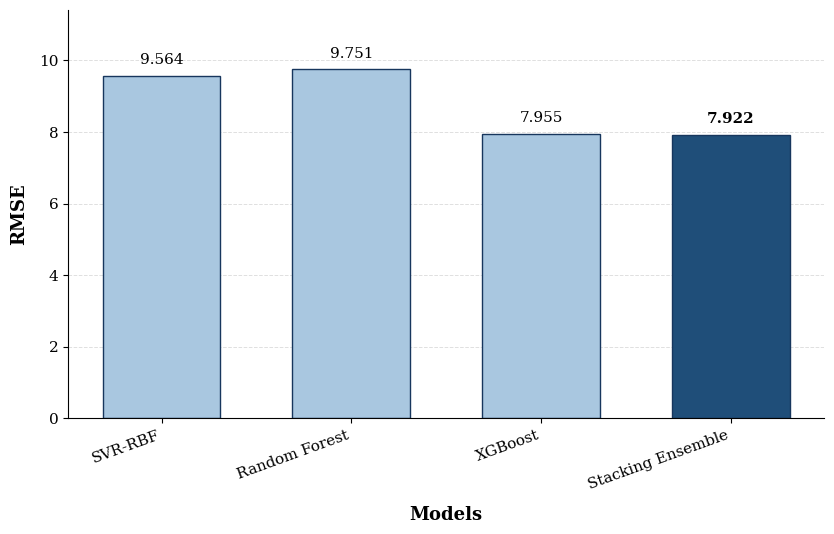

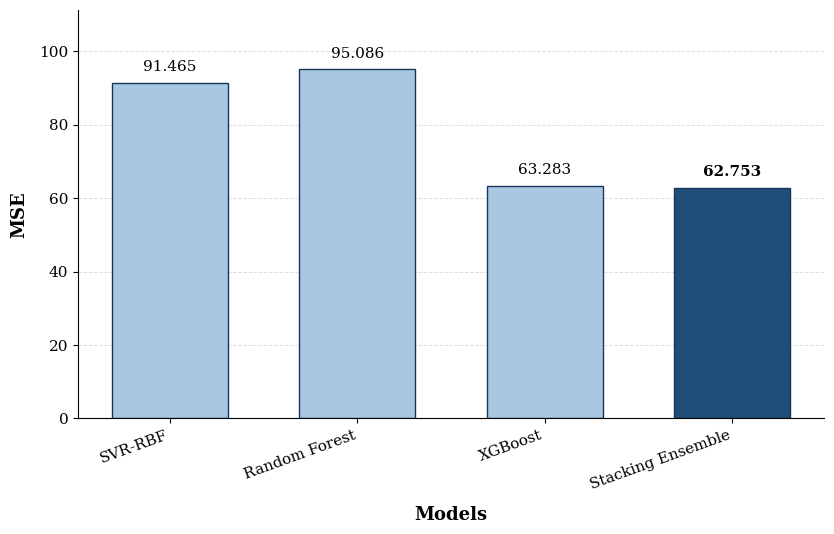

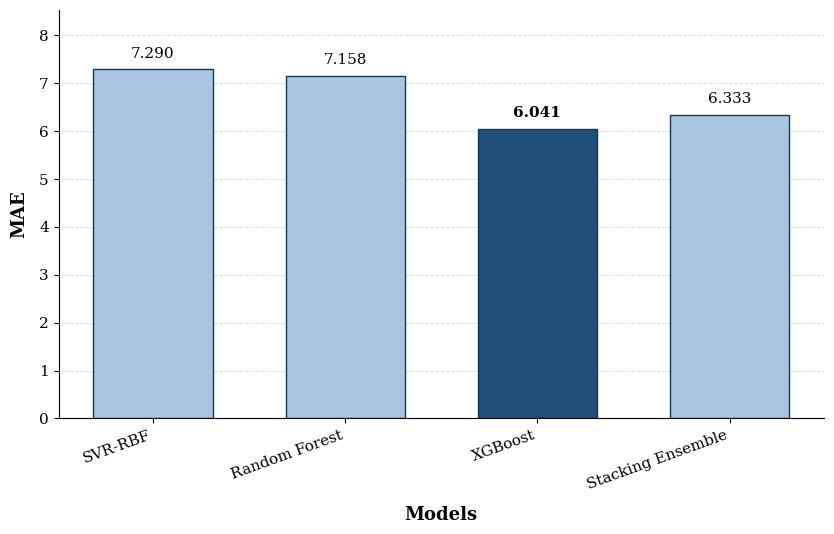

In [44]:
plot_bar(
    metrics_df,
    "R2",
    os.path.join(OUTPUT_DIR, "r2_score_comparison_ml_models.png")
)

plot_bar(
    metrics_df,
    "RMSE",
    os.path.join(OUTPUT_DIR, "rmse_comparison_ml_models.png")
)

plot_bar(
    metrics_df,
    "MSE",
    os.path.join(OUTPUT_DIR, "mse_comparison_ml_models.png")
)

plot_bar(
    metrics_df,
    "MAE",
    os.path.join(OUTPUT_DIR, "mae_comparison_ml_models.png")
)

In [45]:
from sklearn.metrics import r2_score

def plot_combined_predicted_vs_actual(y_true, preds_dict, output_path):
    """
    Create a combined 2 x 2 actual-versus-predicted figure
    for classical machine learning models with R² shown
    in each subplot.
    """

    y_true = np.asarray(y_true)

    preferred_order = [
        "SVR_RBF",
        "Random_Forest",
        "XGBoost",
        "Stacking_Ensemble"
    ]

    # Include available models in the preferred order
    ordered_models = [
        model for model in preferred_order if model in preds_dict
    ]

    # Handle alternative stacking model name, if present
    if "Stacking_Combined" in preds_dict and "Stacking_Ensemble" not in preds_dict:
        ordered_models.append("Stacking_Combined")

    # Add any remaining models
    ordered_models += [
        model for model in preds_dict.keys()
        if model not in ordered_models
    ]

    all_predictions = [
        np.asarray(preds_dict[model]) for model in ordered_models
    ]

    # Use common axis limits for fair visual comparison
    overall_min = min(
        np.min(y_true),
        min(np.min(pred) for pred in all_predictions)
    )

    overall_max = max(
        np.max(y_true),
        max(np.max(pred) for pred in all_predictions)
    )

    padding = (overall_max - overall_min) * 0.07
    lower_limit = overall_min - padding
    upper_limit = overall_max + padding

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11, 10),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    subplot_labels = ["(a)", "(b)", "(c)", "(d)"]

    for i, (ax, model_name) in enumerate(zip(axes, ordered_models)):
        y_pred = np.asarray(preds_dict[model_name])

        display_name = MODEL_LABELS.get(
            model_name,
            model_name.replace("_", " ")
        )

        # Calculate R² for the current model
        r2 = r2_score(y_true, y_pred)

        # Scatter points
        ax.scatter(
            y_true,
            y_pred,
            s=55,
            alpha=0.80,
            color="#2E75B6",
            edgecolor="white",
            linewidth=0.6
        )

        # Perfect agreement line
        ax.plot(
            [lower_limit, upper_limit],
            [lower_limit, upper_limit],
            linestyle="--",
            linewidth=1.8,
            color="#C00000"
        )

        ax.set_xlim(lower_limit, upper_limit)
        ax.set_ylim(lower_limit, upper_limit)

        ax.set_title(
            f"{subplot_labels[i]} {display_name}",
            fontsize=13,
            fontweight="bold",
            pad=9
        )

        # Show R² value inside the plot
        ax.text(
            0.05,
            0.92,
            rf"$R^2$ = {r2:.3f}",
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor="gray",
                alpha=0.85
            )
        )

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.6,
            alpha=0.30
        )

        ax.set_axisbelow(True)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Remove empty subplots, if any
    for ax in axes[len(ordered_models):]:
        fig.delaxes(ax)

    fig.supxlabel(
        "Actual GSI",
        fontsize=14,
        fontweight="bold"
    )

    fig.supylabel(
        "Predicted GSI",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0.04, 0.04, 1, 1])

    plt.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

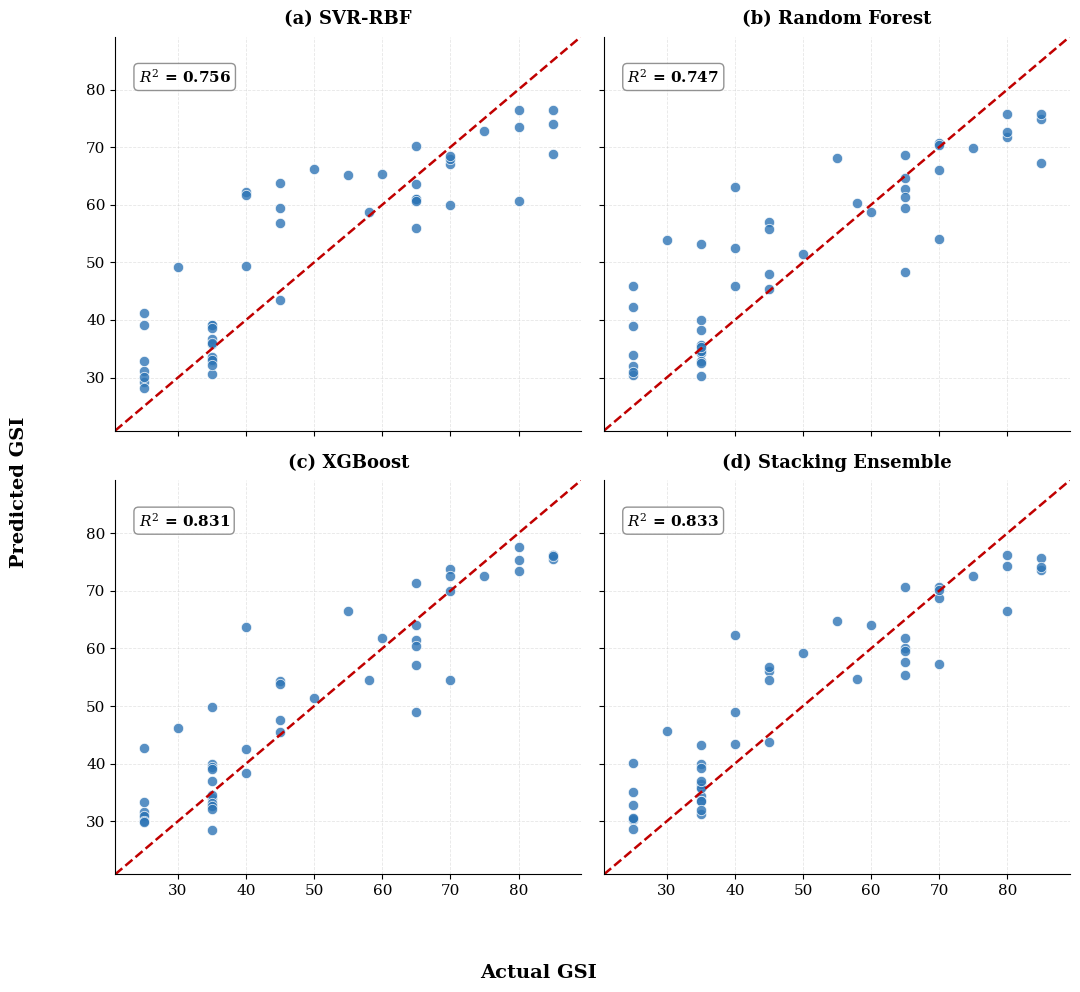

In [46]:
plot_combined_predicted_vs_actual(
    y_test,
    predictions,
    os.path.join(OUTPUT_DIR, "combined_actual_vs_predicted_ml_models_with_r2.png")
)

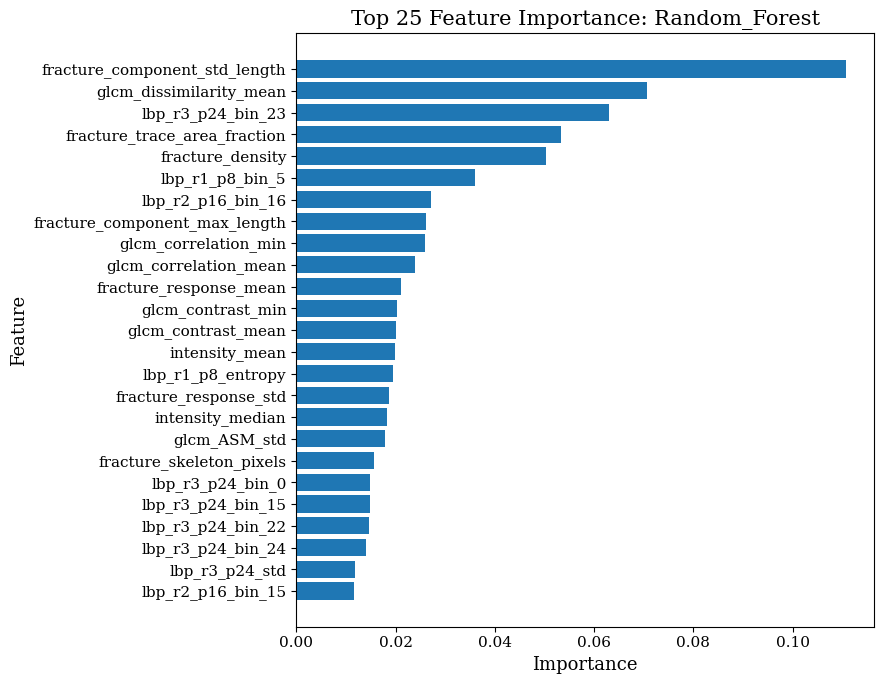

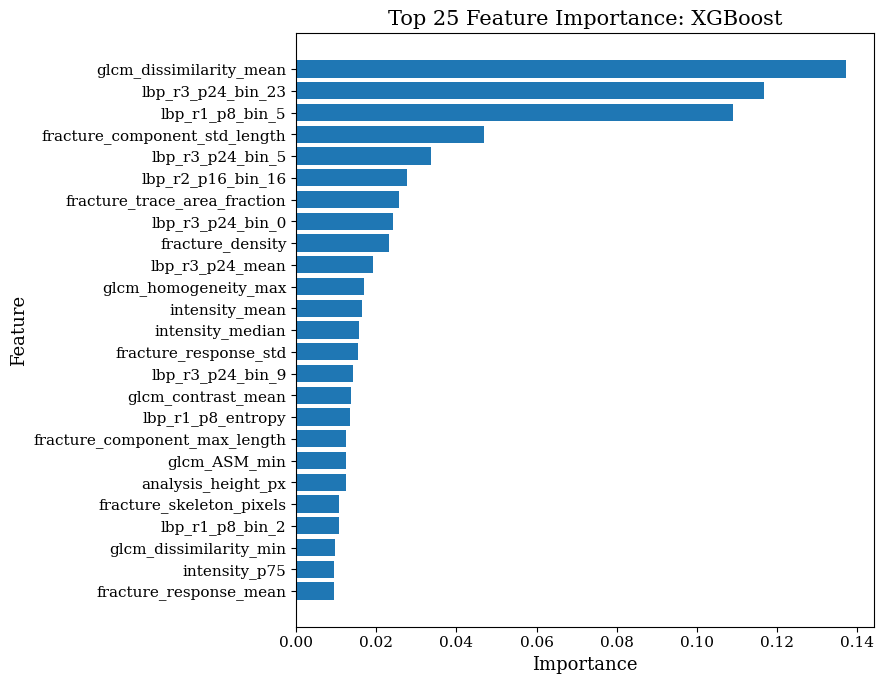

Calculating permutation importance for SVR. This may take some time.


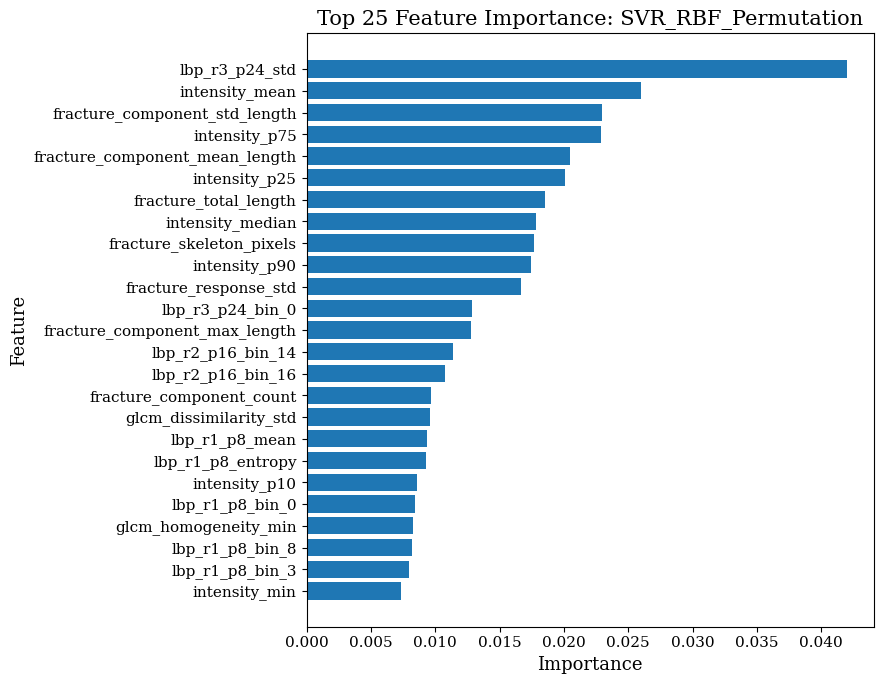

Saved feature importance Excel file:
/kaggle/working/gsi_rock_mass_outputs/feature_importance_all_models.xlsx


In [47]:
def save_feature_importance_plot(importance_df, model_name, output_dir, top_n=25):
    df_imp = importance_df.sort_values(
        "importance",
        ascending=False
    ).head(top_n)

    plt.figure(figsize=(9, 7))

    plt.barh(
        df_imp["feature"][::-1],
        df_imp["importance"][::-1]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Feature Importance: {model_name}")

    plt.tight_layout()

    save_path = os.path.join(
        output_dir,
        f"feature_importance_{model_name}.png"
    )

    plt.savefig(save_path, dpi=300)
    plt.show()


feature_importance_sheets = {}

# Random Forest feature importance
if "Random_Forest" in trained_models:
    rf_model = trained_models["Random_Forest"]

    rf_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False)

    feature_importance_sheets["Random_Forest"] = rf_importance

    save_feature_importance_plot(
        rf_importance,
        "Random_Forest",
        OUTPUT_DIR
    )


# XGBoost feature importance
if "XGBoost" in trained_models:
    xgb_model = trained_models["XGBoost"]

    xgb_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    feature_importance_sheets["XGBoost"] = xgb_importance

    save_feature_importance_plot(
        xgb_importance,
        "XGBoost",
        OUTPUT_DIR
    )


# Permutation importance for SVR
if "SVR_RBF" in trained_models:
    print("Calculating permutation importance for SVR. This may take some time.")

    perm = permutation_importance(
        trained_models["SVR_RBF"],
        X_test,
        y_test,
        n_repeats=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    svr_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance", ascending=False)

    feature_importance_sheets["SVR_RBF_Permutation"] = svr_importance

    save_feature_importance_plot(
        svr_importance,
        "SVR_RBF_Permutation",
        OUTPUT_DIR
    )


importance_excel_path = os.path.join(
    OUTPUT_DIR,
    "feature_importance_all_models.xlsx"
)

with pd.ExcelWriter(importance_excel_path, engine="openpyxl") as writer:
    for sheet_name, imp_df in feature_importance_sheets.items():
        imp_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )

print("Saved feature importance Excel file:")
print(importance_excel_path)

Saved feature-GSI correlation Excel file:
/kaggle/working/gsi_rock_mass_outputs/feature_correlation_with_gsi.xlsx


,feature,pearson_correlation_with_GSI,spearman_correlation_with_GSI,abs_pearson,abs_spearman
44,glcm_correlation_mean,0.708590,0.691507,0.708590,0.691507
46,glcm_correlation_min,0.697874,0.691877,0.697874,0.691877
9,fracture_response_mean,-0.679649,-0.685411,0.679649,0.685411
47,glcm_correlation_max,0.663568,0.656428,0.663568,0.656428
28,glcm_dissimilarity_mean,-0.658429,-0.655889,0.658429,0.655889
30,glcm_dissimilarity_min,-0.652139,-0.648618,0.652139,0.648618
10,fracture_response_std,-0.648303,-0.638364,0.648303,0.638364
32,glcm_homogeneity_mean,0.645732,0.662002,0.645732,0.662002
26,glcm_contrast_min,-0.641829,-0.642477,0.641829,0.642477
6,fracture_component_mean_length,0.640975,0.681995,0.640975,0.681995


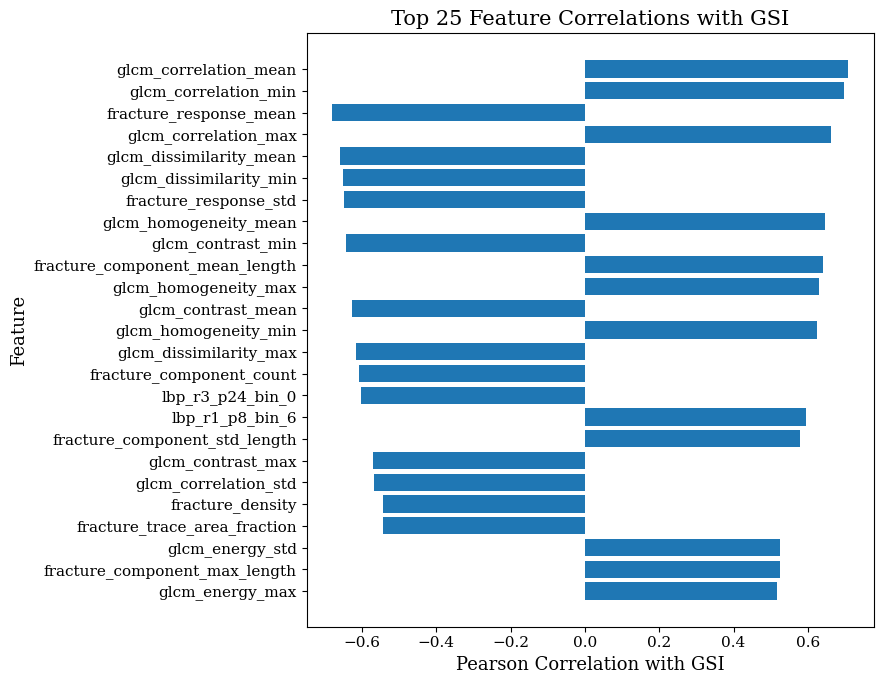

In [48]:
corr_rows = []

for col in feature_cols:
    try:
        pearson_corr = features_df[[col, "GSI"]].corr(method="pearson").iloc[0, 1]
        spearman_corr = features_df[[col, "GSI"]].corr(method="spearman").iloc[0, 1]

        corr_rows.append({
            "feature": col,
            "pearson_correlation_with_GSI": pearson_corr,
            "spearman_correlation_with_GSI": spearman_corr,
            "abs_pearson": abs(pearson_corr),
            "abs_spearman": abs(spearman_corr)
        })

    except Exception:
        pass

corr_df = pd.DataFrame(corr_rows)

corr_df = corr_df.sort_values(
    "abs_pearson",
    ascending=False
)

corr_excel_path = os.path.join(
    OUTPUT_DIR,
    "feature_correlation_with_gsi.xlsx"
)

corr_df.to_excel(corr_excel_path, index=False)

print("Saved feature-GSI correlation Excel file:")
print(corr_excel_path)

display(corr_df.head(20))


# Plot top 25 correlations
top_corr = corr_df.head(25)

plt.figure(figsize=(9, 7))

plt.barh(
    top_corr["feature"][::-1],
    top_corr["pearson_correlation_with_GSI"][::-1]
)

plt.xlabel("Pearson Correlation with GSI")
plt.ylabel("Feature")
plt.title("Top 25 Feature Correlations with GSI")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "top_feature_correlation_with_gsi.png"),
    dpi=300
)

plt.show()

In [49]:
summary_excel_path = os.path.join(
    OUTPUT_DIR,
    "gsi_prediction_complete_results.xlsx"
)

with pd.ExcelWriter(summary_excel_path, engine="openpyxl") as writer:
    features_df.to_excel(
        writer,
        sheet_name="Extracted_Features",
        index=False
    )

    metrics_df.to_excel(
        writer,
        sheet_name="Model_Metrics",
        index=False
    )

    corr_df.to_excel(
        writer,
        sheet_name="Feature_GSI_Correlation",
        index=False
    )

    for sheet_name, imp_df in feature_importance_sheets.items():
        imp_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )

print("Complete Excel summary saved to:")
print(summary_excel_path)

Complete Excel summary saved to:
/kaggle/working/gsi_rock_mass_outputs/gsi_prediction_complete_results.xlsx


In [50]:
zip_path = "/kaggle/working/gsi_rock_mass_outputs_updated.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name="/kaggle/working/gsi_rock_mass_outputs_updated",
    format="zip",
    root_dir=OUTPUT_DIR
)

print("All results zipped here:")
print(zip_path)

All results zipped here:
/kaggle/working/gsi_rock_mass_outputs_updated.zip


In [51]:
# ============================================================
# Selected images: step-by-step joint/fracture detection outputs
# Run this after updated Cell 5 and after Cell 4 matched_df is available
# ============================================================

import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

SELECTED_RM_IDS = ["RM_0004", "RM_0174", "RM_0195", "RM_0308"]

STEP_OUTPUT_DIR = os.path.join(
    OUTPUT_DIR,
    "selected_joint_detection_steps"
)

os.makedirs(STEP_OUTPUT_DIR, exist_ok=True)


def clean_id_for_matching(x):
    """
    Cleans RM_ID values such as RM_0004\t\t or RM-0004.
    """
    s = str(x)
    s = s.replace("\t", "")
    s = s.replace("\\t", "")
    s = s.replace("\n", "")
    s = s.replace("\r", "")
    s = s.strip()
    s = re.sub(r"\s+", "", s)

    match = re.search(r"RM[_-]?\d+", s, flags=re.IGNORECASE)

    if match:
        clean_id = match.group(0).upper()
        clean_id = clean_id.replace("-", "_")
        clean_id = re.sub(r"RM_?", "RM_", clean_id)
        return clean_id

    return s


def save_gray_step(array, save_path, title="", cmap="gray"):
    """
    Save grayscale or response map with colorbar.
    """
    plt.figure(figsize=(7, 6))
    plt.imshow(array, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()


def save_binary_step(mask, save_path, title=""):
    """
    Save binary mask as black-white image.
    """
    plt.figure(figsize=(7, 6))
    plt.imshow(mask.astype(np.uint8), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()


def save_overlay_step(gray, mask, skeleton_img, save_path, title=""):
    """
    Save overlay:
    Green = detected fracture mask
    Red = final skeleton used for fractal dimension
    """
    gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0

    overlay = gray_rgb.copy()

    mask_bool = mask.astype(bool)
    skel_bool = skeleton_img.astype(bool)

    overlay[mask_bool] = (
        0.65 * overlay[mask_bool]
        + 0.35 * np.array([0.0, 1.0, 0.0], dtype=np.float32)
    )

    overlay[skel_bool] = np.array([1.0, 0.0, 0.0], dtype=np.float32)

    plt.figure(figsize=(7, 6))
    plt.imshow(np.clip(overlay, 0, 1))
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()


def save_box_count_plot(binary_skeleton, save_path, rm_id):
    """
    Save box-counting log-log plot for fractal dimension.
    """
    binary_skeleton = binary_skeleton.astype(bool)

    height, width = binary_skeleton.shape
    min_dim = min(height, width)

    sizes = []
    size = 2

    while size <= min_dim // 2:
        sizes.append(size)
        size *= 2

    counts = []

    for box_size in sizes:
        rows = int(np.ceil(height / box_size))
        cols = int(np.ceil(width / box_size))

        count = 0

        for row in range(rows):
            row_slice = slice(row * box_size, min((row + 1) * box_size, height))

            for col in range(cols):
                col_slice = slice(col * box_size, min((col + 1) * box_size, width))

                if binary_skeleton[row_slice, col_slice].any():
                    count += 1

        counts.append(max(count, 1))

    if len(sizes) >= 2:
        log_inv_size = np.log(1.0 / np.array(sizes, dtype=np.float64))
        log_count = np.log(np.array(counts, dtype=np.float64))
        fd = float(np.polyfit(log_inv_size, log_count, deg=1)[0])
    else:
        log_inv_size = np.array([])
        log_count = np.array([])
        fd = 0.0

    box_df = pd.DataFrame({
        "box_size_px": sizes,
        "occupied_boxes": counts
    })

    box_df.to_csv(
        save_path.replace(".png", "_table.csv"),
        index=False
    )

    plt.figure(figsize=(7, 5))

    if len(sizes) >= 2:
        plt.scatter(log_inv_size, log_count)

        fit_line = np.poly1d(np.polyfit(log_inv_size, log_count, deg=1))
        plt.plot(log_inv_size, fit_line(log_inv_size))

    plt.xlabel("log(1 / box size)")
    plt.ylabel("log(occupied boxes)")
    plt.title(f"{rm_id} Box-counting fractal dimension = {fd:.4f}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    return fd, box_df


def save_joint_detection_steps_for_one_image(rm_id, image_path):
    """
    Run the same improved fracture detector step-by-step
    and save every important intermediate output separately.
    """

    rm_dir = os.path.join(STEP_OUTPUT_DIR, rm_id)
    os.makedirs(rm_dir, exist_ok=True)

    # ------------------------------------------------------------
    # Step 1: Load grayscale image
    # ------------------------------------------------------------
    gray = load_grayscale_image(image_path, MAX_IMAGE_SIZE)

    save_gray_step(
        gray,
        os.path.join(rm_dir, "01_original_grayscale.png"),
        f"{rm_id}: Original grayscale",
        cmap="gray"
    )

    # ------------------------------------------------------------
    # Step 2: Local normalization
    # ------------------------------------------------------------
    gray_float = gray.astype(np.float32)

    if gray_float.max() > 1.5:
        gray_float = gray_float / 255.0

    normalized = normalize_gray(gray_float)

    save_gray_step(
        normalized,
        os.path.join(rm_dir, "02_locally_normalized.png"),
        f"{rm_id}: Locally normalized image",
        cmap="gray"
    )

    # ------------------------------------------------------------
    # Step 3: Hessian / Frangi dark-line response
    # ------------------------------------------------------------
    hessian_response, normal_angle = frangi_dark_response(normalized)

    save_gray_step(
        hessian_response,
        os.path.join(rm_dir, "03_hessian_frangi_dark_line_response.png"),
        f"{rm_id}: Hessian / Frangi dark-line response",
        cmap="magma"
    )

    # ------------------------------------------------------------
    # Step 4: Valley response
    # ------------------------------------------------------------
    valley = valley_emphasis(normalized, normal_angle)

    save_gray_step(
        valley,
        os.path.join(rm_dir, "04_valley_response.png"),
        f"{rm_id}: Valley response",
        cmap="magma"
    )

    # ------------------------------------------------------------
    # Step 5: Black-hat response
    # ------------------------------------------------------------
    black_hat = ndimage.grey_closing(normalized, size=(9, 9)) - normalized
    black_hat = rescale01(black_hat)

    save_gray_step(
        black_hat,
        os.path.join(rm_dir, "05_black_hat_response.png"),
        f"{rm_id}: Black-hat response",
        cmap="magma"
    )

    # ------------------------------------------------------------
    # Step 6: Local darkness response
    # ------------------------------------------------------------
    local_darkness = np.maximum(
        ndimage.gaussian_filter(normalized, sigma=5.0) - normalized,
        0.0
    )
    local_darkness = rescale01(local_darkness)

    save_gray_step(
        local_darkness,
        os.path.join(rm_dir, "06_local_darkness_response.png"),
        f"{rm_id}: Local darkness response",
        cmap="magma"
    )

    # ------------------------------------------------------------
    # Step 7: Paper-style high-pass / line response
    # ------------------------------------------------------------
    paper_response = paper_style_response(normalized)

    save_gray_step(
        paper_response,
        os.path.join(rm_dir, "07_paper_style_response.png"),
        f"{rm_id}: Paper-style response",
        cmap="magma"
    )

    # ------------------------------------------------------------
    # Step 8: Directional line response
    # ------------------------------------------------------------
    line_response = directional_line_response(normalized)

    save_gray_step(
        line_response,
        os.path.join(rm_dir, "08_directional_line_response.png"),
        f"{rm_id}: Directional line response",
        cmap="magma"
    )

    # ------------------------------------------------------------
    # Step 9: Combined fracture response
    # ------------------------------------------------------------
    combined = (
        0.36 * hessian_response
        + 0.19 * valley
        + 0.14 * black_hat
        + 0.21 * paper_response
        + 0.10 * line_response
    )

    combined = rescale01(combined)

    save_gray_step(
        combined,
        os.path.join(rm_dir, "09_combined_fracture_response.png"),
        f"{rm_id}: Combined fracture response",
        cmap="magma"
    )

    # ------------------------------------------------------------
    # Step 10: Adaptive masks from combined, paper, and line response
    # ------------------------------------------------------------
    combined_mask, combined_threshold = adaptive_response_mask(
        combined,
        otsu_scale=0.92,
        min_fraction=0.025,
        max_fraction=0.20
    )

    paper_mask, paper_threshold = adaptive_response_mask(
        paper_response,
        otsu_scale=1.02,
        min_fraction=0.018,
        max_fraction=0.14
    )

    line_mask, line_threshold = adaptive_response_mask(
        line_response,
        otsu_scale=1.08,
        min_fraction=0.010,
        max_fraction=0.08
    )

    save_binary_step(
        combined_mask,
        os.path.join(rm_dir, "10_combined_adaptive_mask.png"),
        f"{rm_id}: Combined adaptive mask"
    )

    save_binary_step(
        paper_mask,
        os.path.join(rm_dir, "11_paper_response_mask.png"),
        f"{rm_id}: Paper response mask"
    )

    save_binary_step(
        line_mask,
        os.path.join(rm_dir, "12_directional_line_mask.png"),
        f"{rm_id}: Directional line mask"
    )

    # ------------------------------------------------------------
    # Step 11: Contrast guard
    # ------------------------------------------------------------
    contrast_guard = (
        (local_darkness > 0.030)
        | (valley > 0.016)
        | (paper_response >= paper_threshold)
        | (line_response >= line_threshold)
    )

    save_binary_step(
        contrast_guard,
        os.path.join(rm_dir, "13_contrast_guard.png"),
        f"{rm_id}: Contrast guard"
    )

    # ------------------------------------------------------------
    # Step 12: High-confidence and low-confidence fracture regions
    # ------------------------------------------------------------
    binary_high = (
        (combined >= max(combined_threshold, float(np.quantile(combined, 0.88))))
        | (paper_mask & (hessian_response > 0.12))
    )

    binary_low = (combined_mask | paper_mask | line_mask) & contrast_guard

    save_binary_step(
        binary_high,
        os.path.join(rm_dir, "14_binary_high_confidence_regions.png"),
        f"{rm_id}: High-confidence fracture regions"
    )

    save_binary_step(
        binary_low,
        os.path.join(rm_dir, "15_binary_low_confidence_support_regions.png"),
        f"{rm_id}: Low-confidence support regions"
    )

    # ------------------------------------------------------------
    # Step 13: Binary propagation
    # ------------------------------------------------------------
    propagated_binary = ndimage.binary_propagation(
        binary_high,
        mask=binary_low,
        structure=np.ones((3, 3), dtype=bool)
    )

    save_binary_step(
        propagated_binary,
        os.path.join(rm_dir, "16_binary_propagation_result.png"),
        f"{rm_id}: Binary propagation result"
    )

    # ------------------------------------------------------------
    # Step 14: Raw binary fracture candidate map
    # ------------------------------------------------------------
    raw_binary = propagated_binary.copy()
    raw_binary |= combined_mask & contrast_guard
    raw_binary |= line_mask & (combined > float(np.quantile(combined, 0.70)))

    save_binary_step(
        raw_binary,
        os.path.join(rm_dir, "17_raw_binary_fracture_candidate_map.png"),
        f"{rm_id}: Raw binary fracture candidate map"
    )

    # ------------------------------------------------------------
    # Step 15: Clean fracture mask
    # ------------------------------------------------------------
    display_mask = clean_candidate_mask(raw_binary, combined)

    save_binary_step(
        display_mask,
        os.path.join(rm_dir, "18_cleaned_fracture_mask.png"),
        f"{rm_id}: Cleaned fracture mask"
    )

    # ------------------------------------------------------------
    # Step 16: Skeleton of detected fracture mask
    # ------------------------------------------------------------
    display_skeleton = morphological_skeleton(display_mask)

    save_binary_step(
        display_skeleton,
        os.path.join(rm_dir, "19_display_skeleton.png"),
        f"{rm_id}: Skeleton of fracture mask"
    )

    # ------------------------------------------------------------
    # Step 17: Metric mask after component filtering
    # ------------------------------------------------------------
    metric_mask = filter_components(display_mask, combined)

    save_binary_step(
        metric_mask,
        os.path.join(rm_dir, "20_metric_mask_after_component_filtering.png"),
        f"{rm_id}: Metric mask after component filtering"
    )

    # ------------------------------------------------------------
    # Step 18: Final trace skeleton used for fractal dimension
    # ------------------------------------------------------------
    trace_skeleton = display_skeleton & metric_mask
    trace_skeleton = remove_small_components(trace_skeleton, min_size=6)

    if display_skeleton.any() and float(trace_skeleton.sum()) < 0.35 * float(display_skeleton.sum()):
        trace_skeleton = remove_small_components(display_skeleton, min_size=6)

    trace_skeleton = prune_skeleton(trace_skeleton, iterations=1)

    save_binary_step(
        trace_skeleton,
        os.path.join(rm_dir, "21_final_trace_skeleton_for_fractal_dimension.png"),
        f"{rm_id}: Final trace skeleton for fractal dimension"
    )

    # ------------------------------------------------------------
    # Step 19: Final overlay
    # ------------------------------------------------------------
    save_overlay_step(
        gray,
        display_mask,
        trace_skeleton,
        os.path.join(rm_dir, "22_final_overlay_mask_green_skeleton_red.png"),
        f"{rm_id}: Green = fracture mask, Red = skeleton"
    )

    # ------------------------------------------------------------
    # Step 20: Box-counting fractal dimension plot
    # ------------------------------------------------------------
    fd, box_df = save_box_count_plot(
        trace_skeleton,
        os.path.join(rm_dir, "23_box_counting_fractal_dimension_plot.png"),
        rm_id
    )

    # ------------------------------------------------------------
    # Save summary
    # ------------------------------------------------------------
    h, w = gray.shape
    area = h * w

    summary = {
        "RM_ID": rm_id,
        "image_path": image_path,
        "combined_threshold": combined_threshold,
        "paper_threshold": paper_threshold,
        "line_threshold": line_threshold,
        "fractal_dimension": fd,
        "fracture_mask_area_fraction": float(display_mask.mean()),
        "trace_skeleton_area_fraction": float(trace_skeleton.mean()),
        "skeleton_pixels": int(trace_skeleton.sum()),
        "fracture_total_length_px": float(skeleton_length(trace_skeleton)),
        "fracture_density": float(trace_skeleton.sum() / area),
        "analysis_height_px": int(h),
        "analysis_width_px": int(w),
    }

    summary_df = pd.DataFrame([summary])

    summary_df.to_csv(
        os.path.join(rm_dir, "24_summary_features.csv"),
        index=False
    )

    return summary


# ============================================================
# Match selected RM IDs from matched_df
# ============================================================

temp_df = matched_df.copy()
temp_df["_clean_RM_ID_"] = temp_df[id_col].apply(clean_id_for_matching)

summary_rows = []

for rm_id in SELECTED_RM_IDS:
    rows = temp_df[temp_df["_clean_RM_ID_"] == rm_id]

    if rows.empty:
        print(f"Not found in matched_df: {rm_id}")
        continue

    image_path = rows.iloc[0]["image_path"]

    print(f"Processing {rm_id}: {image_path}")

    summary = save_joint_detection_steps_for_one_image(
        rm_id=rm_id,
        image_path=image_path
    )

    summary_rows.append(summary)

summary_all_df = pd.DataFrame(summary_rows)

summary_all_path = os.path.join(
    STEP_OUTPUT_DIR,
    "selected_images_joint_detection_summary.csv"
)

summary_all_df.to_csv(summary_all_path, index=False)

print("\nDone.")
print("All step-by-step files saved in:")
print(STEP_OUTPUT_DIR)
print("\nSummary saved to:")
print(summary_all_path)

display(summary_all_df)

Processing RM_0004: /kaggle/input/datasets/younasafridi/msc-research1/MS Mining Engineering/MS Mining Engineering/RM_0004.png
Processing RM_0174: /kaggle/input/datasets/younasafridi/msc-research1/MS Mining Engineering/MS Mining Engineering/RM_0174.png
Processing RM_0195: /kaggle/input/datasets/younasafridi/msc-research1/MS Mining Engineering/MS Mining Engineering/RM_0195.png
Processing RM_0308: /kaggle/input/datasets/younasafridi/msc-research1/MS Mining Engineering/MS Mining Engineering/RM_0308.png

Done.
All step-by-step files saved in:
/kaggle/working/gsi_rock_mass_outputs/selected_joint_detection_steps

Summary saved to:
/kaggle/working/gsi_rock_mass_outputs/selected_joint_detection_steps/selected_images_joint_detection_summary.csv


,RM_ID,image_path,combined_threshold,paper_threshold,line_threshold,fractal_dimension,fracture_mask_area_fraction,trace_skeleton_area_fraction,skeleton_pixels,fracture_total_length_px,fracture_density,analysis_height_px,analysis_width_px
0,RM_0004,/kaggle/input/datasets/younasafridi/msc-resear...,0.167109,0.203721,0.302691,1.501619,0.185496,0.044556,18102,22319.305612,0.044556,529,768
1,RM_0174,/kaggle/input/datasets/younasafridi/msc-resear...,0.134766,0.137461,0.232701,1.524370,0.192170,0.046518,20578,25034.387648,0.046518,576,768
2,RM_0195,/kaggle/input/datasets/younasafridi/msc-resear...,0.149141,0.165352,0.264832,1.479055,0.163714,0.038610,17080,20103.045876,0.038610,768,576
3,RM_0308,/kaggle/input/datasets/younasafridi/msc-resear...,0.138359,0.148250,0.296059,1.534810,0.194888,0.048622,21509,25673.586566,0.048622,576,768


In [52]:
# ============================================================
# Zip complete GSI output folder
# ============================================================

import os
import shutil

FULL_OUTPUT_DIR = "/kaggle/working/gsi_rock_mass_outputs"

ZIP_BASE_PATH = "/kaggle/working/gsi_rock_mass_outputs"
ZIP_PATH = ZIP_BASE_PATH + ".zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(
    base_name=ZIP_BASE_PATH,
    format="zip",
    root_dir=FULL_OUTPUT_DIR
)

print("Complete output zip created successfully:")
print(ZIP_PATH)

Complete output zip created successfully:
/kaggle/working/gsi_rock_mass_outputs.zip


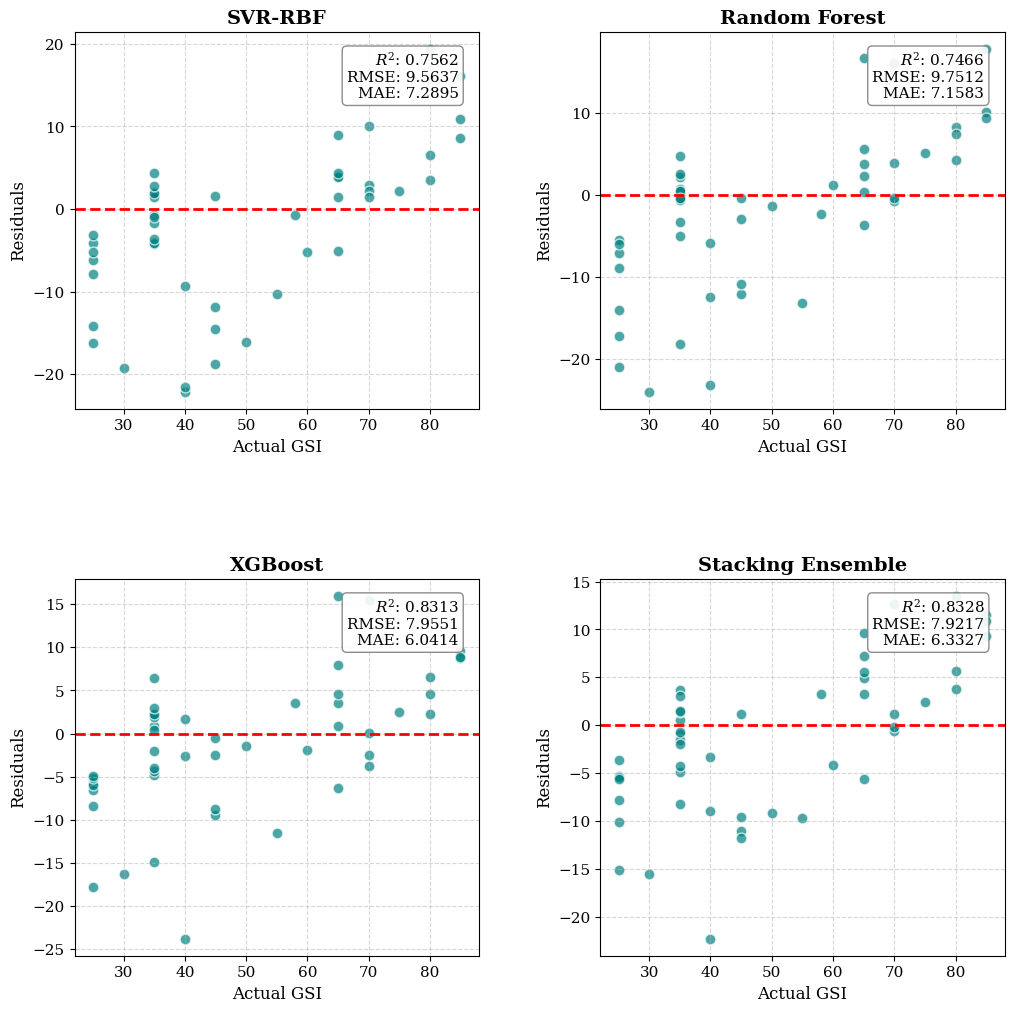

In [53]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def plot_combined_actual_vs_residual_with_metrics(y_true, preds_dict, output_path):
    """
    Create a combined 2 x 2 actual-versus-residual figure
    specifically for SVR, RF, XGBoost, and Stacking Ensemble, 
    with R², RMSE, and MAE shown in each subplot to match thesis styling.
    """
    y_true = np.asarray(y_true)
    
    target_models = [
        "SVR_RBF",
        "Random_Forest",
        "XGBoost",
        "Stacking_Combined" 
    ]
    
    ordered_models = [m for m in target_models if m in preds_dict]
    
    # FIX 1: Set figure to 12x12 for maximum vertical space
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for idx, model_name in enumerate(ordered_models):
        if idx >= 4:
            break
            
        ax = axes[idx]
        y_pred = preds_dict[model_name]
        residuals = y_true - y_pred
        
        r2 = r2_score(y_true, y_pred)
        rmse = math.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        
        display_name = MODEL_LABELS.get(model_name, model_name.replace("_", " "))
        
        ax.scatter(y_true, residuals, alpha=0.7, edgecolors='white', s=60, color='teal')
        ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
        
        ax.set_title(display_name, fontsize=14, fontweight='bold')
        ax.set_xlabel("Actual GSI", fontsize=12)
        ax.set_ylabel("Residuals", fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.5)
        
        text_str = f"$R^2$: {r2:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}"
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
        
        # Securely place text box in the top right
        ax.text(0.95, 0.95, text_str, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right', bbox=props)
        
    for idx in range(len(ordered_models), len(axes)):
        fig.delaxes(axes[idx])
        
    # FIX 2: Explicitly force row spacing (hspace) and column spacing (wspace)
    # This prevents the x-axis of the top row from hitting the titles of the bottom row.
    plt.subplots_adjust(hspace=0.45, wspace=0.3)
    
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# Execute the plotting function
plot_combined_actual_vs_residual_with_metrics(
    y_test, 
    predictions, 
    os.path.join(OUTPUT_DIR, "combined_actual_vs_residual_thesis_style.png")
)

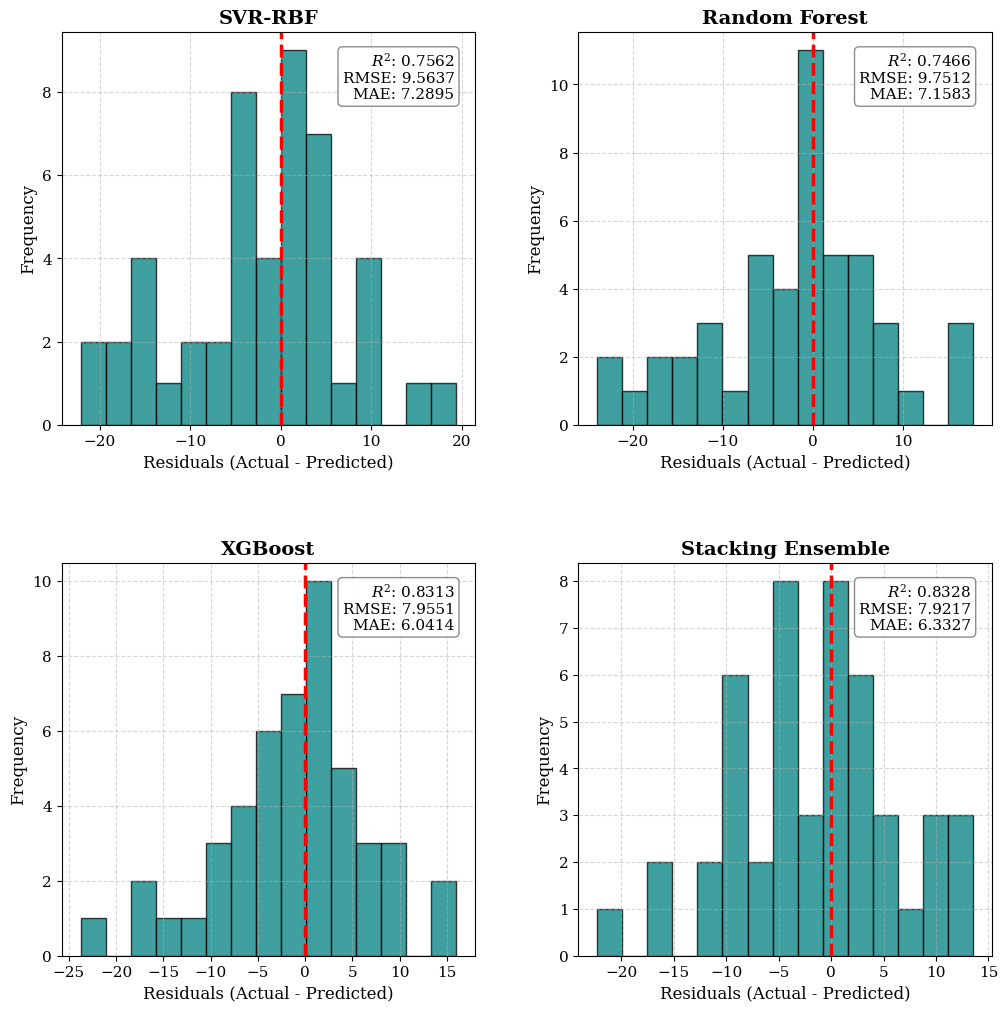

In [54]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def plot_combined_residual_histogram_with_metrics(y_true, preds_dict, output_path):
    """
    Create a combined 2 x 2 residual frequency histogram figure
    specifically for SVR, RF, XGBoost, and Stacking Ensemble, 
    with R², RMSE, and MAE shown in each subplot to match thesis styling.
    """
    y_true = np.asarray(y_true)
    
    target_models = [
        "SVR_RBF",
        "Random_Forest",
        "XGBoost",
        "Stacking_Combined" 
    ]
    
    ordered_models = [m for m in target_models if m in preds_dict]
    
    # 12x12 canvas provides plenty of room
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for idx, model_name in enumerate(ordered_models):
        if idx >= 4:
            break
            
        ax = axes[idx]
        y_pred = preds_dict[model_name]
        residuals = y_true - y_pred  # Actual - Predicted
        
        r2 = r2_score(y_true, y_pred)
        rmse = math.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        
        display_name = MODEL_LABELS.get(model_name, model_name.replace("_", " "))
        
        # PLOT HISTOGRAM (Frequency on Y, Residuals on X)
        # bins=15 adjusts how granular the bars are. Change if needed.
        ax.hist(residuals, bins=15, alpha=0.75, color='teal', edgecolor='black')
        
        # Vertical line indicating perfect prediction (0 residual)
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2.5)
        
        # Axis labels and titles
        ax.set_title(display_name, fontsize=14, fontweight='bold')
        ax.set_xlabel("Residuals (Actual - Predicted)", fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.5)
        
        # Metrics Box
        text_str = f"$R^2$: {r2:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}"
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
        
        # Place text box in the top right
        ax.text(0.95, 0.95, text_str, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right', bbox=props)
        
    # Clear any unused subplots
    for idx in range(len(ordered_models), len(axes)):
        fig.delaxes(axes[idx])
        
    # Explicitly force row and column spacing
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    
    # Save the figure
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# Execute the plotting function
plot_combined_residual_histogram_with_metrics(
    y_test, 
    predictions, 
    os.path.join(OUTPUT_DIR, "combined_residual_histogram_thesis_style.png")
)

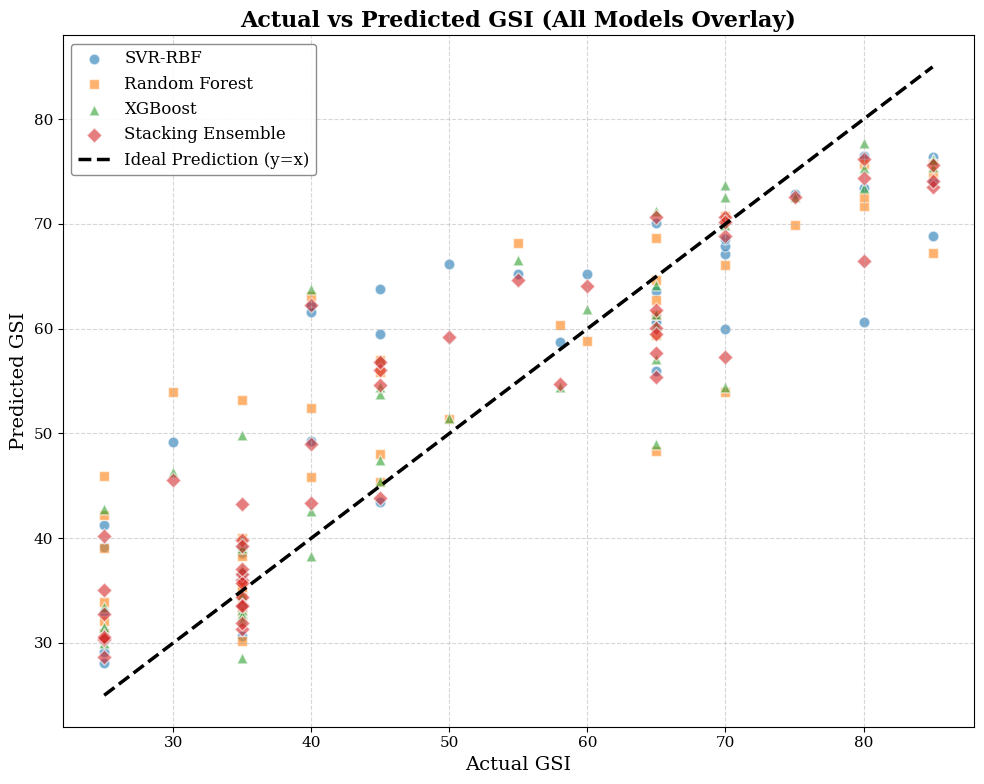

In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_all_models_overlaid(y_true, preds_dict, output_path):
    """
    Plots Actual vs Predicted values for all models overlaid on a 
    single graph, saving to one PNG file.
    """
    plt.figure(figsize=(10, 8))
    
    # Models to include
    target_models = ["SVR_RBF", "Random_Forest", "XGBoost", "Stacking_Combined"]
    ordered_models = [m for m in target_models if m in preds_dict]
    
    # Distinct colors and marker shapes for each model
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
    markers = ['o', 's', '^', 'D'] # Circle, Square, Triangle, Diamond
    
    # Plot each model's predictions
    for idx, model_name in enumerate(ordered_models):
        y_pred = preds_dict[model_name]
        display_name = MODEL_LABELS.get(model_name, model_name.replace("_", " "))
        
        plt.scatter(
            y_true, y_pred, 
            alpha=0.6, 
            label=display_name, 
            color=colors[idx], 
            marker=markers[idx], 
            edgecolors='white', 
            s=60
        )
        
    # Draw the Ideal Prediction Line (y = x)
    # Calculate the min and max limits based on all data points
    all_preds = [val for m in ordered_models for val in preds_dict[m]]
    min_val = min(np.min(y_true), np.min(all_preds))
    max_val = max(np.max(y_true), np.max(all_preds))
    
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2.5, label="Ideal Prediction (y=x)")
    
    # Formatting
    plt.title("Actual vs Predicted GSI (All Models Overlay)", fontsize=16, fontweight='bold')
    plt.xlabel("Actual GSI", fontsize=14)
    plt.ylabel("Predicted GSI", fontsize=14)
    
    # Add a legend
    plt.legend(fontsize=12, loc='best', framealpha=0.9, edgecolor='gray')
    plt.grid(True, linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    
    # Save to a single PNG file
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# Execute the plotting function
plot_all_models_overlaid(
    y_test, 
    predictions, 
    os.path.join(OUTPUT_DIR, "all_models_overlaid_scatter.png")
)

Pearson Correlation Matrix:


,fractal_dimension_box_counting,fracture_total_length,fracture_skeleton_pixels,fracture_density,fracture_length_density,fracture_component_count,fracture_component_mean_length,fracture_component_std_length,fracture_component_max_length,fracture_response_mean,...,lbp_r3_p24_bin_19,lbp_r3_p24_bin_20,lbp_r3_p24_bin_21,lbp_r3_p24_bin_22,lbp_r3_p24_bin_23,lbp_r3_p24_bin_24,lbp_r3_p24_bin_25,lbp_r3_p24_mean,lbp_r3_p24_std,lbp_r3_p24_entropy
fractal_dimension_box_counting,1.000000,0.857748,0.868986,0.217015,0.262584,0.583471,0.038055,-0.070286,-0.040176,0.218435,...,-0.137475,-0.111398,-0.098546,0.026008,0.172292,0.170923,0.071110,0.048065,0.314393,-0.085019
fracture_total_length,0.857748,1.000000,0.995853,-0.036815,0.038601,0.430938,0.289018,0.130703,0.141926,-0.007007,...,0.090608,0.112284,0.114258,0.180679,-0.075288,-0.044894,-0.151691,-0.162534,0.164766,0.161707
fracture_skeleton_pixels,0.868986,0.995853,1.000000,0.000459,0.057943,0.484071,0.246710,0.089412,0.102772,0.034522,...,0.034557,0.055905,0.057902,0.133837,-0.014310,0.006819,-0.104641,-0.114705,0.177210,0.108968
fracture_density,0.217015,-0.036815,0.000459,1.000000,0.974967,0.608430,-0.619604,-0.453281,-0.361435,0.869706,...,-0.659724,-0.637023,-0.604434,-0.368001,0.744077,0.776478,0.616148,0.578529,0.658689,-0.683721
fracture_length_density,0.262584,0.038601,0.057943,0.974967,1.000000,0.551896,-0.540998,-0.377186,-0.283644,0.827209,...,-0.557157,-0.529548,-0.493160,-0.255026,0.634267,0.696809,0.527289,0.482824,0.698435,-0.583931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lbp_r3_p24_bin_24,0.170923,-0.044894,0.006819,0.776478,0.696809,0.596682,-0.503312,-0.375964,-0.326912,0.699288,...,-0.821225,-0.803225,-0.766792,-0.537421,0.854419,1.000000,0.764643,0.783103,0.412867,-0.828521
lbp_r3_p24_bin_25,0.071110,-0.151691,-0.104641,0.616148,0.527289,0.442843,-0.420033,-0.323346,-0.307307,0.504492,...,-0.946168,-0.939850,-0.903830,-0.623432,0.924009,0.764643,1.000000,0.991184,0.339342,-0.985443
lbp_r3_p24_mean,0.048065,-0.162534,-0.114705,0.578529,0.482824,0.408227,-0.379356,-0.275667,-0.262694,0.459845,...,-0.935508,-0.933544,-0.899269,-0.628514,0.914252,0.783103,0.991184,1.000000,0.244856,-0.977270
lbp_r3_p24_std,0.314393,0.164766,0.177210,0.658689,0.698435,0.596300,-0.541881,-0.545843,-0.490513,0.692704,...,-0.339052,-0.277959,-0.203442,0.085496,0.375973,0.412867,0.339342,0.244856,1.000000,-0.354653


Saved correlation heatmap to: /kaggle/working/gsi_rock_mass_outputs/pearson_correlation_matrix.png


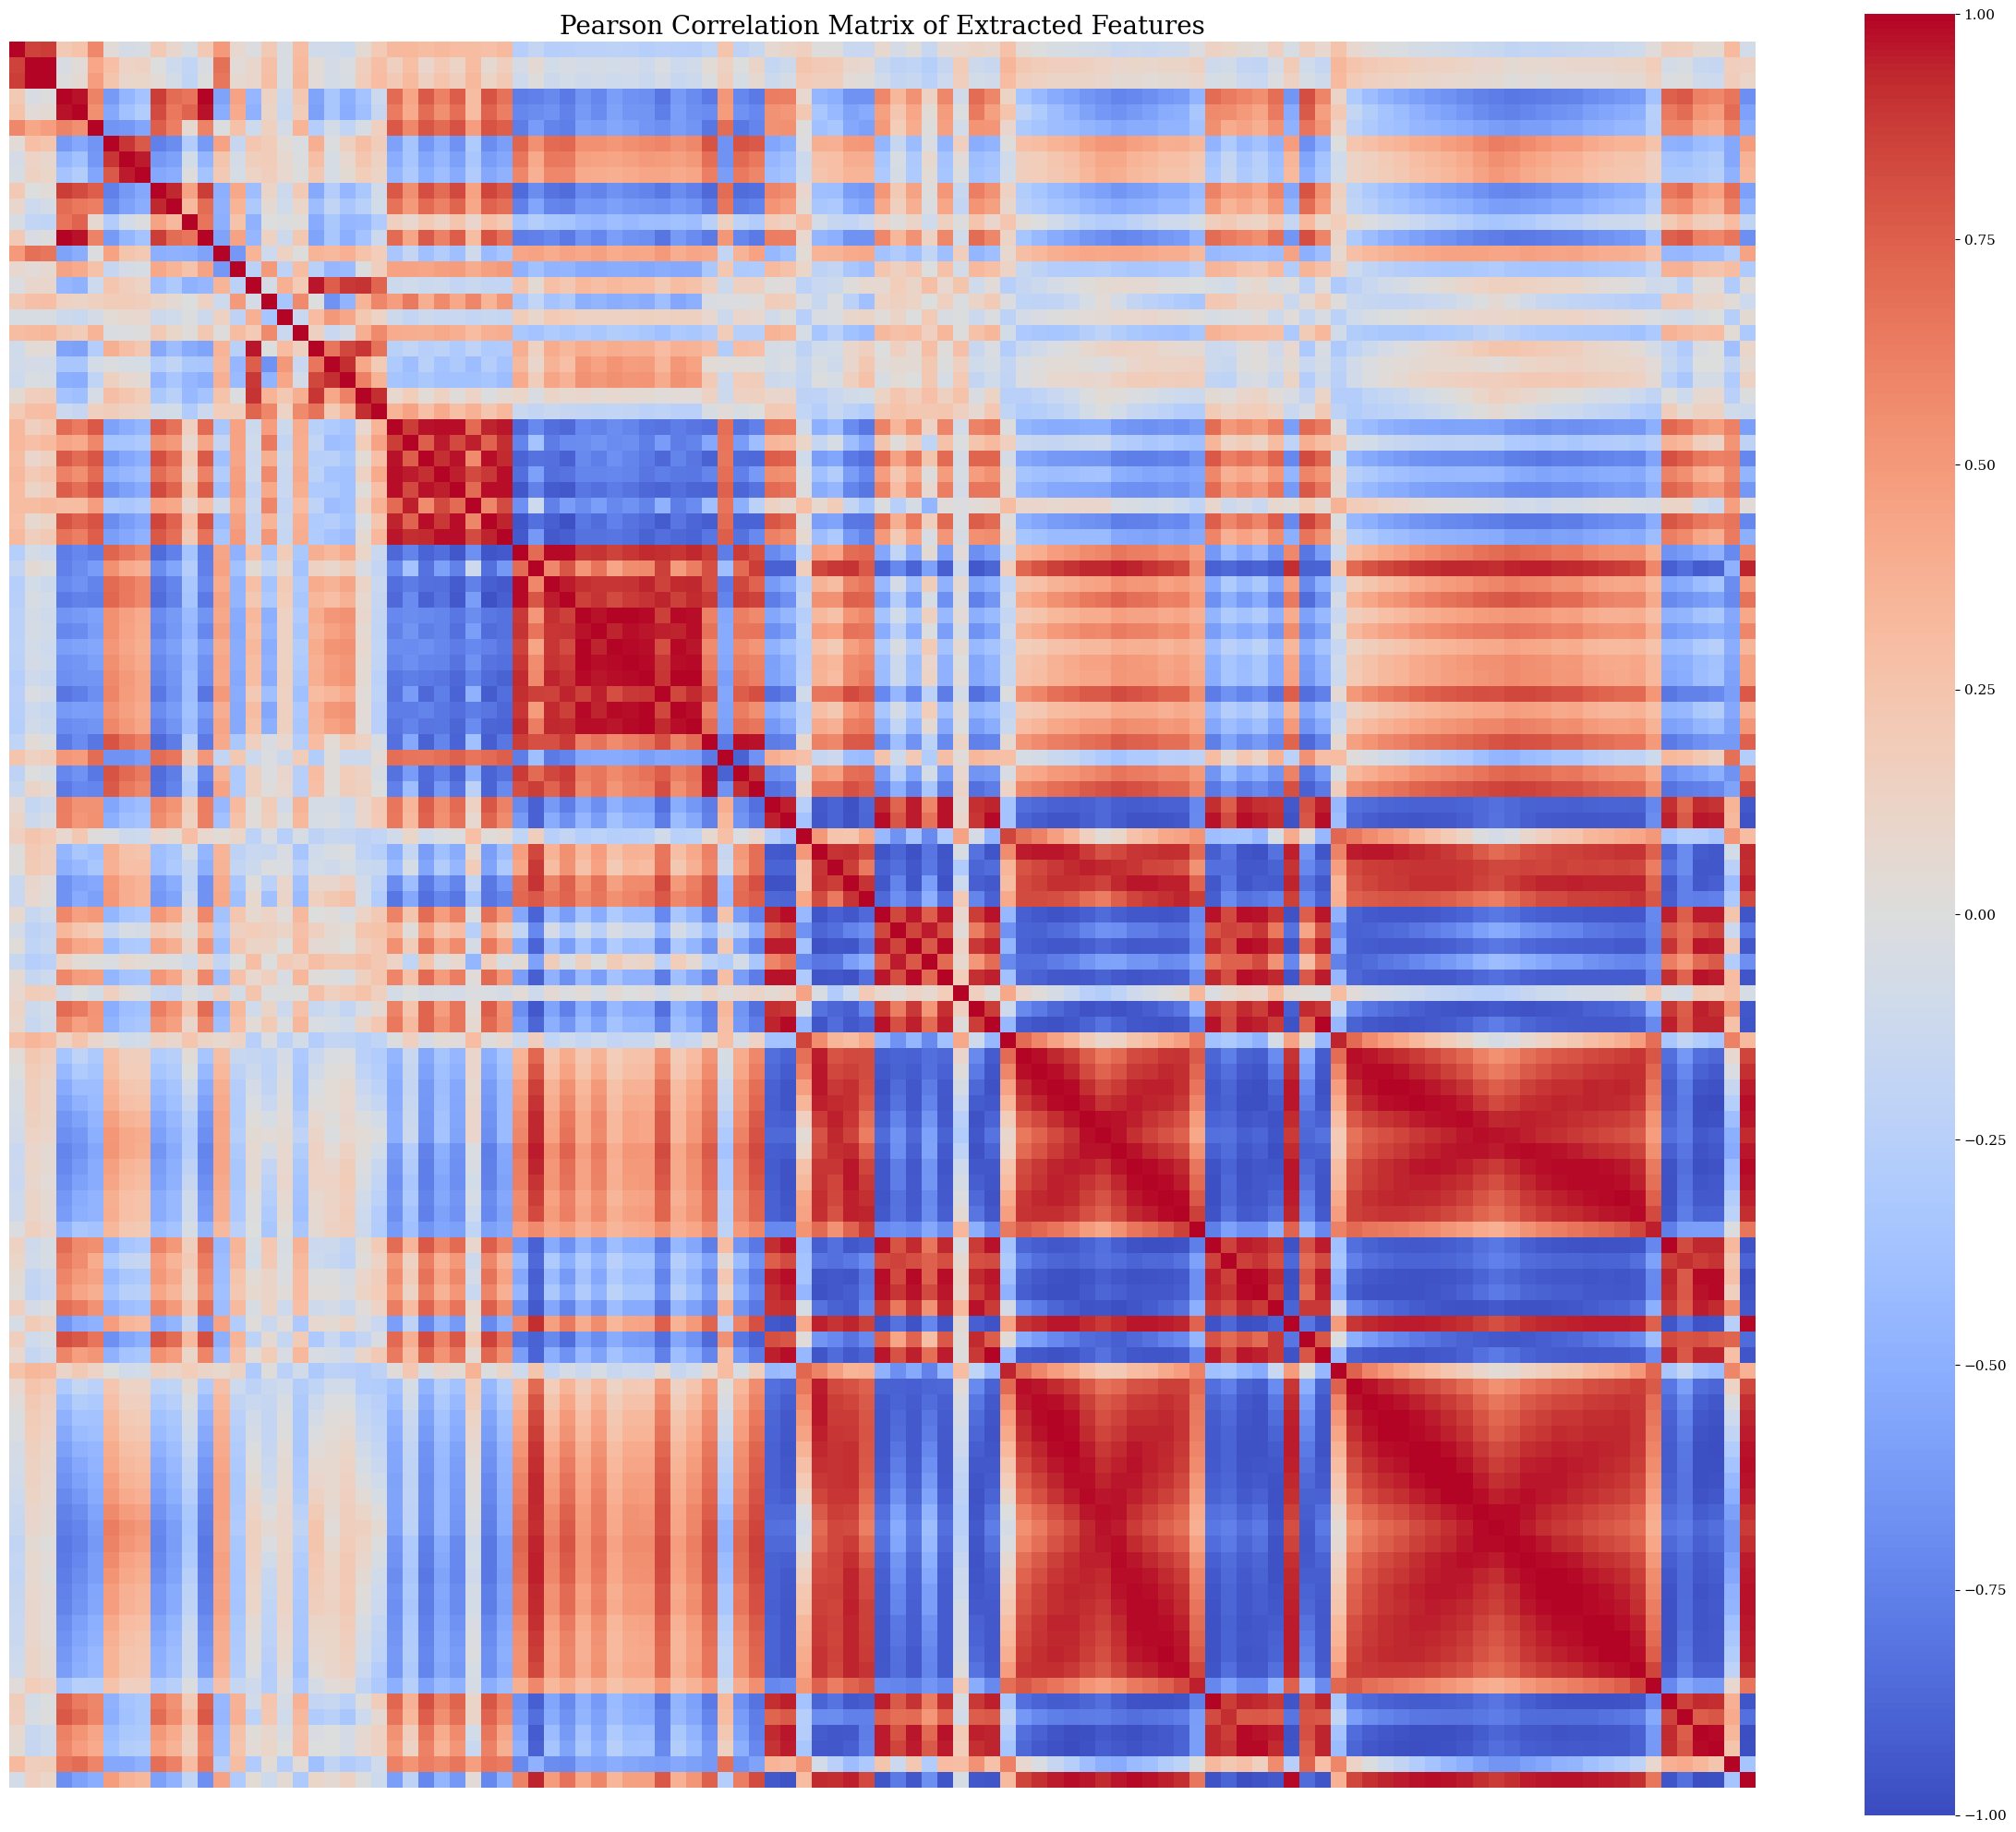

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the Pearson correlation matrix using the 'X' DataFrame
corr_matrix = X.corr(method='pearson')

# 2. Display the raw numerical correlation dataframe
print("Pearson Correlation Matrix:")
display(corr_matrix)

# 3. Plot a heatmap for visual interpretation
plt.figure(figsize=(24, 20))
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm', 
    annot=False,          # Set to True if you want to see the numbers (will be very cluttered for 111 features)
    fmt=".2f", 
    vmin=-1, 
    vmax=1, 
    square=True,
    xticklabels=False,    # Hidden for cleaner viewing of large feature sets; set to True to see feature names
    yticklabels=False
)
plt.title('Pearson Correlation Matrix of Extracted Features', fontsize=20)
plt.tight_layout()

# Save the matrix image to your output directory
output_path = os.path.join(OUTPUT_DIR, "pearson_correlation_matrix.png")
plt.savefig(output_path, dpi=300)
print(f"Saved correlation heatmap to: {output_path}")

plt.show()

In [57]:
import numpy as np
import pandas as pd

def drop_redundant_features(X, y_target, threshold=0.98):
    """
    Identifies highly correlated feature pairs (> threshold) and drops the 
    feature that has a lower absolute correlation with the target variable.
    """
    print("Calculating correlations...")
    
    # 1. Calculate absolute correlation of each feature with the GSI target
    # We use .abs() because a strong negative correlation is just as important as a strong positive one
    target_corr = X.corrwith(y_target).abs()
    
    # 2. Calculate the absolute correlation matrix of the features
    corr_matrix = X.corr(method='pearson').abs()
    
    # 3. Extract the upper triangle of the correlation matrix to avoid checking pairs twice
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    features_to_drop = set()
    
    # 4. Iterate through the upper triangle to find correlated pairs
    for col in upper_tri.columns:
        # Find rows (other features) that are highly correlated with this column
        highly_correlated_features = upper_tri.index[upper_tri[col] > threshold].tolist()
        
        for row in highly_correlated_features:
            # If both features are already in the drop set, skip
            if col in features_to_drop and row in features_to_drop:
                continue
                
            # Compare their correlation with the GSI target
            if target_corr[col] > target_corr[row]:
                features_to_drop.add(row)  # Drop 'row' feature, keep 'col'
            else:
                features_to_drop.add(col)  # Drop 'col' feature, keep 'row'
                
    # 5. Drop the identified features from the dataset
    X_reduced = X.drop(columns=list(features_to_drop))
    
    print(f"Original feature count: {X.shape[1]}")
    print(f"Features dropped: {len(features_to_drop)}")
    print(f"Remaining feature count: {X_reduced.shape[1]}")
    
    return X_reduced, list(features_to_drop)

# ==========================================
# HOW TO EXECUTE THIS IN YOUR NOTEBOOK
# ==========================================

# Assuming your target variable is named 'GSI' and is in your original dataframe 'df'
# Replace `df['GSI']` with however you access your GSI labels in your notebook
gsi_target = df['GSI Value'] 

# Run the function on your existing 'X' dataframe
X_filtered, dropped_features = drop_redundant_features(X, gsi_target, threshold=0.98)

# View the features that were removed
print("\nList of dropped features:")
print(dropped_features)

Calculating correlations...
Original feature count: 111
Features dropped: 48
Remaining feature count: 63

List of dropped features:
['fracture_trace_area_fraction', 'lbp_r3_p24_mean', 'lbp_r3_p24_bin_5', 'lbp_r2_p16_bin_15', 'lbp_r2_p16_bin_5', 'glcm_ASM_std', 'lbp_r3_p24_bin_17', 'lbp_r3_p24_entropy', 'glcm_dissimilarity_min', 'lbp_r3_p24_bin_8', 'lbp_r2_p16_bin_10', 'lbp_r3_p24_bin_19', 'glcm_ASM_min', 'lbp_r3_p24_bin_12', 'lbp_r1_p8_bin_9', 'lbp_r3_p24_bin_14', 'glcm_ASM_max', 'glcm_ASM_mean', 'lbp_r2_p16_bin_12', 'lbp_r3_p24_bin_18', 'lbp_r3_p24_bin_7', 'lbp_r1_p8_bin_1', 'lbp_r3_p24_bin_20', 'lbp_r2_p16_std', 'lbp_r2_p16_bin_7', 'lbp_r3_p24_bin_9', 'lbp_r1_p8_bin_7', 'lbp_r2_p16_bin_17', 'lbp_r3_p24_bin_10', 'lbp_r3_p24_bin_16', 'fracture_skeleton_pixels', 'lbp_r3_p24_bin_6', 'lbp_r2_p16_mean', 'lbp_r2_p16_bin_1', 'lbp_r3_p24_bin_21', 'glcm_homogeneity_max', 'glcm_energy_min', 'lbp_r2_p16_bin_9', 'lbp_r3_p24_bin_11', 'lbp_r3_p24_bin_3', 'lbp_r2_p16_bin_11', 'glcm_energy_mean', 'lb

In [58]:
import math
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# Ensure RANDOM_STATE is defined
RANDOM_STATE = 42

print("Starting Hyperparameter Optimization across 5-Fold Cross Validation...\n")

# ============================================================
# 1. TUNE SVR (GridSearchCV)
# ============================================================
print("--> Tuning SVR (RBF)...")
svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

svr_param_grid = {
    "model__C": [10, 50, 100, 200],
    "model__gamma": ["scale", "auto", 0.01, 0.05, 0.1],
    "model__epsilon": [0.1, 0.5, 1.0, 2.0]
}

grid_svr = GridSearchCV(
    svr_pipe, 
    svr_param_grid, 
    cv=5, 
    scoring="r2", 
    n_jobs=-1
)
grid_svr.fit(X_train_reduced, y_train)

best_svr = grid_svr.best_estimator_
print(f"Best SVR Cross-Val R²: {grid_svr.best_score_:.4f}")
print(f"Best SVR Params: {grid_svr.best_params_}\n")


# ============================================================
# 2. TUNE RANDOM FOREST (RandomizedSearchCV)
# ============================================================
print("--> Tuning Random Forest...")
rf_param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 4, 6, 8],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.8, 1.0]
}

search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
search_rf.fit(X_train_reduced, y_train)

best_rf = search_rf.best_estimator_
print(f"Best Random Forest Cross-Val R²: {search_rf.best_score_:.4f}")
print(f"Best RF Params: {search_rf.best_params_}\n")


# ============================================================
# 3. TUNE XGBOOST (RandomizedSearchCV)
# ============================================================
if XGBOOST_AVAILABLE:
    print("--> Tuning XGBoost...")
    xgb_param_dist = {
        "n_estimators": [200, 300, 500, 700],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "reg_alpha": [0.0, 0.1, 1.0],
        "reg_lambda": [0.1, 1.0, 5.0]
    }

    search_xgb = RandomizedSearchCV(
        XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=xgb_param_dist,
        n_iter=25,
        cv=5,
        scoring="r2",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search_xgb.fit(X_train_reduced, y_train)

    best_xgb = search_xgb.best_estimator_
    print(f"Best XGBoost Cross-Val R²: {search_xgb.best_score_:.4f}")
    print(f"Best XGB Params: {search_xgb.best_params_}\n")


# ============================================================
# 4. BUILD TUNED STACKING ENSEMBLE
# ============================================================
print("--> Building Stacking Ensemble with Tuned Models...")
estimators_for_stack = [
    ("svr", best_svr),
    ("rf", best_rf)
]

if XGBOOST_AVAILABLE:
    estimators_for_stack.append(("xgb", best_xgb))

best_stacking = StackingRegressor(
    estimators=estimators_for_stack,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)
best_stacking.fit(X_train_reduced, y_train)


# ============================================================
# 5. FINAL EVALUATION ON HOLD-OUT TEST SET
# ============================================================
tuned_models = {
    "SVR_RBF": best_svr,
    "Random_Forest": best_rf,
    "Stacking_Combined": best_stacking
}

if XGBOOST_AVAILABLE:
    tuned_models["XGBoost"] = best_xgb

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae}

metrics_list = []
predictions = {}

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test_reduced)
    predictions[model_name] = y_pred
    
    m = regression_metrics(y_test, y_pred)
    m["Model"] = model_name
    metrics_list.append(m)

# Format into clean metrics DataFrame
metrics_df = pd.DataFrame(metrics_list)[["Model", "R2", "MSE", "RMSE", "MAE"]]
metrics_df = metrics_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("="*50)
print("     OPTIMIZED MODEL PERFORMANCE ON TEST SET     ")
print("="*50)
display(metrics_df)

Starting Hyperparameter Optimization across 5-Fold Cross Validation...

--> Tuning SVR (RBF)...


NameError: name 'X_train_reduced' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Combine the filtered features with the GSI target column
# (Using 'gsi_target' from the previous step)
df_reduced = X_filtered.copy()
df_reduced['GSI Value'] = gsi_target

# 2. Compute Pearson correlation matrix
corr_reduced = df_reduced.corr(method='pearson')

# 3. Create the heatmap plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_reduced, 
    annot=True,         # Displays correlation numbers inside each cell
    fmt=".2f",          # Formats numbers to 2 decimal places
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True,
    linewidths=0.8,
    cbar_kws={"shrink": 0.8}
)

plt.title('Pearson Correlation Matrix (10 Selected Features vs GSI)', fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save image if needed
plt.savefig("filtered_features_correlation.png", dpi=900)

plt.show()

In [ ]:
import math
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# ============================================================
# 1. FILTER TRAIN/TEST SPLITS TO THE 10 SELECTED FEATURES
# ============================================================
X_train_reduced = X_train[X_filtered.columns]
X_test_reduced = X_test[X_filtered.columns]

print(f"Training dataset shape: {X_train_reduced.shape}")
print(f"Testing dataset shape:  {X_test_reduced.shape}\n")

# ============================================================
# 2. INITIALIZE MODELS FROM MLCODE.IPYNB
# ============================================================
models = {}

# Model 1: Support Vector Regressor (RBF Kernel)
models["SVR_RBF"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=50,
        gamma="scale",
        epsilon=2.0
    ))
])

# Model 2: Random Forest Regressor
models["Random_Forest"] = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Model 3: XGBoost Regressor
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

# Model 4: Stacking Ensemble
estimators_for_stack = [
    ("svr", models["SVR_RBF"]),
    ("rf", models["Random_Forest"])
]

if XGBOOST_AVAILABLE:
    estimators_for_stack.append(("xgb", models["XGBoost"]))

models["Stacking_Combined"] = StackingRegressor(
    estimators=estimators_for_stack,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

# ============================================================
# 3. TRAINING & EVALUATION LOOP
# ============================================================
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae}

metrics_list = []
predictions = {}
trained_models = {}

print("--- Training Models ---")
for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Train model on reduced 10 features
    model.fit(X_train_reduced, y_train)
    
    # Predict on reduced test set
    y_pred = model.predict(X_test_reduced)
    
    # Store artifacts
    trained_models[model_name] = model
    predictions[model_name] = y_pred
    
    # Calculate metrics
    m = regression_metrics(y_test, y_pred)
    m["Model"] = model_name
    metrics_list.append(m)

# Format into DataFrame and sort by best R² score
metrics_df = pd.DataFrame(metrics_list)[["Model", "R2", "MSE", "RMSE", "MAE"]]
metrics_df = metrics_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("     MODEL PERFORMANCE SUMMARY (10 FEATURES)     ")
print("="*50)
display(metrics_df)

In [ ]:
# ============================================================
# Save trained models and prediction artifacts for future use
# ============================================================

import os
import json
import joblib
import shutil
import sklearn
import numpy as np
import pandas as pd

MODEL_OUTPUT_DIR = "/kaggle/working/gsi_saved_models"
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Save feature columns
# These columns must be used in the same order during future prediction
# ------------------------------------------------------------

feature_schema_path = os.path.join(MODEL_OUTPUT_DIR, "feature_columns.json")

with open(feature_schema_path, "w") as f:
    json.dump(feature_cols, f, indent=4)

print("Saved feature columns:")
print(feature_schema_path)


# ------------------------------------------------------------
# 2. Save feature median values
# These are used to fill missing values during future prediction
# ------------------------------------------------------------

feature_medians = X.median(numeric_only=True).to_dict()

feature_median_path = os.path.join(MODEL_OUTPUT_DIR, "feature_medians.json")

with open(feature_median_path, "w") as f:
    json.dump(feature_medians, f, indent=4)

print("Saved feature medians:")
print(feature_median_path)


# ------------------------------------------------------------
# 3. Save all trained models
# ------------------------------------------------------------

all_models_path = os.path.join(MODEL_OUTPUT_DIR, "all_trained_models.joblib")

joblib.dump(trained_models, all_models_path)

print("Saved all trained models:")
print(all_models_path)


# ------------------------------------------------------------
# 4. Save each model separately
# ------------------------------------------------------------

single_model_dir = os.path.join(MODEL_OUTPUT_DIR, "individual_models")
os.makedirs(single_model_dir, exist_ok=True)

for model_name, model in trained_models.items():
    model_path = os.path.join(single_model_dir, f"{model_name}.joblib")
    joblib.dump(model, model_path)
    print(f"Saved {model_name}: {model_path}")


# ------------------------------------------------------------
# 5. Select and save best model
# Best model is selected based on lowest RMSE
# ------------------------------------------------------------

best_row = metrics_df.sort_values("RMSE", ascending=True).iloc[0]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

best_model_path = os.path.join(MODEL_OUTPUT_DIR, "best_gsi_model.joblib")

joblib.dump(best_model, best_model_path)

print("\nBest model selected based on lowest RMSE:")
print(best_model_name)
print("Saved best model:")
print(best_model_path)


# ------------------------------------------------------------
# 6. Save model metrics
# ------------------------------------------------------------

metrics_save_path = os.path.join(MODEL_OUTPUT_DIR, "model_metrics.csv")
metrics_df.to_csv(metrics_save_path, index=False)

metrics_excel_path = os.path.join(MODEL_OUTPUT_DIR, "model_metrics.xlsx")
metrics_df.to_excel(metrics_excel_path, index=False)

print("Saved model metrics:")
print(metrics_save_path)
print(metrics_excel_path)


# ------------------------------------------------------------
# 7. Save metadata
# Useful for future reproducibility and GUI development
# ------------------------------------------------------------

metadata = {
    "project": "GSI prediction from rock mass images",
    "target": "GSI",
    "best_model_name": str(best_model_name),
    "best_model_R2": float(best_row["R2"]),
    "best_model_MSE": float(best_row["MSE"]),
    "best_model_RMSE": float(best_row["RMSE"]),
    "best_model_MAE": float(best_row["MAE"]),
    "number_of_features": int(len(feature_cols)),
    "number_of_samples": int(len(features_df)),
    "max_image_size": int(MAX_IMAGE_SIZE),
    "test_size": float(TEST_SIZE),
    "random_state": int(RANDOM_STATE),
    "sklearn_version": sklearn.__version__,
}

try:
    import xgboost
    metadata["xgboost_version"] = xgboost.__version__
except Exception:
    metadata["xgboost_version"] = "not_available"

metadata_path = os.path.join(MODEL_OUTPUT_DIR, "model_metadata.json")

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved metadata:")
print(metadata_path)


# ------------------------------------------------------------
# 8. Save README for future use
# ------------------------------------------------------------

readme_text = f"""
GSI Prediction Model Artifacts

Best model:
{best_model_name}

Saved files:
1. best_gsi_model.joblib
   Main model recommended for future prediction and GUI deployment.

2. all_trained_models.joblib
   Dictionary containing all trained models.

3. individual_models/
   Separate joblib file for each trained model.

4. feature_columns.json
   Exact feature names and order required by the model.

5. feature_medians.json
   Median values used to fill missing features during prediction.

6. model_metrics.csv and model_metrics.xlsx
   Performance of trained models.

7. model_metadata.json
   Reproducibility information.

Important:
For future prediction, the new image must pass through the same feature extraction pipeline:
joint/fracture detection + fractal dimension + intensity + GLCM + LBP.

The extracted feature vector must have exactly the same columns as feature_columns.json.
"""

readme_path = os.path.join(MODEL_OUTPUT_DIR, "README.txt")

with open(readme_path, "w") as f:
    f.write(readme_text)

print("Saved README:")
print(readme_path)


# ------------------------------------------------------------
# 9. Create zip file for download
# ------------------------------------------------------------

zip_base = "/kaggle/working/gsi_saved_models"
zip_path = zip_base + ".zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name=zip_base,
    format="zip",
    root_dir=MODEL_OUTPUT_DIR
)

print("\n============================================================")
print("Model saving completed.")
print("Download this zip file:")
print(zip_path)
print("============================================================")